# 10 - Model Diagnostics and Error Analysis

## Objective

Notebook này chẩn đoán lỗi của các model trước khi hyperparameter tuning. Mục tiêu là hiểu model mắc lỗi ở đâu và vì sao, không phải retrain hoặc chọn final model.

| Diagnostic Area | Key Question |
|---|---|
| Overall error | Model nào có error thấp nhất trên original price scale? |
| Residual distribution | Residuals có centered quanh 0 hay lệch hệ thống? |
| Heteroscedasticity | Residual variance có tăng theo actual price không? |
| Price-segment bias | Low-price bị overpredict? Premium bị underpredict? |
| Log-target compression | Log-transform có nén prediction ở vùng giá cao không? |
| Outliers / data quality | Các lỗi cực đại là hard cases hợp lệ hay nhiễu dữ liệu? |
| Exploratory corrections | Hiệu chỉnh post-hoc đơn giản có giảm error pattern chính không? |

> **Important**: Notebook này không thực hiện hyperparameter tuning. Correction experiments chỉ mang tính exploratory, được ước tính trên test set, và không được report như final model performance.

### Model handling

Notebook tự động phát hiện model-target combinations thực sự có trong prediction dataframe theo pattern `pred_<Model>_<target>`. Các model được request ban đầu là CatBoost, LightGBM, và XGBoost, nhưng model nào thiếu prediction columns sẽ được skip và ghi rõ trong validation output.

**Artifacts được load từ**: `artifacts/modeling_numeric/` (output của notebook 07b)


## 1. Imports và Configuration

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    import statsmodels.stats.diagnostic as sm_diag
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not available; formal heteroscedasticity tests will be skipped.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
# Configuration and paths
REQUESTED_MODELS = ["CatBoost", "LightGBM", "XGBoost"]
TARGET_CANDIDATES = ["log_target_price", "target_price"]
PRIMARY_TARGET = "log_target_price"

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "laptop_processed_numeric.csv"

ARTIFACT_DIR    = PROJECT_ROOT / "artifacts" / "modeling_numeric"
METRICS_DIR     = ARTIFACT_DIR / "metrics"
PREDICTIONS_DIR = ARTIFACT_DIR / "predictions"
COMPARISON_DIR  = ARTIFACT_DIR / "target_comparison"
DIAGNOSTICS_DIR = ARTIFACT_DIR / "model_diagnostics"
DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME_FOR_FILE = {"CatBoost": "CatBoost", "LightGBM": "LightGBM", "XGBoost": "XGBoost"}

def safe_filename(model_name: str, target_used: str) -> str:
    base = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(" ", ""))
    return f"{base}_{target_used}"

def expected_prediction_col(model_name: str, target_used: str) -> str:
    return f"pred_{safe_filename(model_name, target_used)}"

def format_model_target_pairs(pairs):
    return ", ".join(f"{m} + {t}" for m, t in pairs) if pairs else "None"

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"DATA_PATH      : {DATA_PATH}")
print(f"DIAGNOSTICS_DIR: {DIAGNOSTICS_DIR}")
print(f"Requested models: {REQUESTED_MODELS}")


PROJECT_ROOT   : Y:\Python\Laptop-Price-Prediction
DATA_PATH      : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
DIAGNOSTICS_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics
Requested models: ['CatBoost', 'LightGBM', 'XGBoost']


## 2. Load Predictions, Metrics và Original Data

Load artifacts đã được lưu bởi notebook 07b. Không có model retraining ở bước này.

In [3]:
# ── Kiểm tra file có sẵn ─────────────────────────────────────────────────────
print('=== Metrics files ===')
for f in sorted(METRICS_DIR.glob('*.csv')):
    print(f'  {f.name}')

print()
print('=== Predictions files ===')
for f in sorted(PREDICTIONS_DIR.glob('*.csv')):
    print(f'  {f.name}')

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Predictions files ===
  test_predictions.csv


In [4]:
# Load metrics
metrics_df = None
metrics_path = None
for candidate in ["model_metrics.csv", "metrics_df.csv", "all_metrics.csv"]:
    p = METRICS_DIR / candidate
    if p.exists():
        metrics_df = pd.read_csv(p)
        metrics_path = p
        print(f"Loaded metrics: {candidate}  shape={metrics_df.shape}")
        break

if metrics_df is None:
    raise FileNotFoundError("No metrics CSV found. Run notebook 07b first.")

metrics_df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in metrics_df.columns]
metrics_df.rename(columns={"median_ae": "median_absolute_error", "train_time_sec": "training_time_seconds"}, inplace=True)
if "mape" in metrics_df.columns and metrics_df["mape"].max() > 10:
    metrics_df["mape"] = metrics_df["mape"] / 100.0

display(metrics_df.head(10))


Loaded metrics: model_metrics.csv  shape=(16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_absolute_error,max_error,training_time_seconds,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.4705,5.4785,0.8653,0.3302,2.1144,36.2442,8.0484,0.0041
1,CatBoost,gradient_boosting,log_target_price,target_price,3.4455,5.6434,0.8571,0.2899,1.9306,37.5938,7.9994,0.0034
2,LightGBM,gradient_boosting,target_price,target_price,3.5269,5.7620,0.8511,0.3200,1.9498,38.6261,1.0455,0.0191
3,LightGBM,gradient_boosting,log_target_price,target_price,3.4375,5.7633,0.8510,0.2893,1.8491,38.5314,1.7507,0.0211
4,Random Forest,tree_ensemble,log_target_price,target_price,3.5388,5.8795,0.8449,0.3051,1.9392,36.1898,1.8360,0.1520
5,Random Forest,tree_ensemble,target_price,target_price,3.5747,5.8937,0.8442,0.3305,1.9434,37.3202,1.8648,0.1742
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.7410,6.1857,0.8283,0.3206,2.0445,45.0000,2.1408,0.1710
7,Extra Trees,tree_ensemble,target_price,target_price,3.8199,6.2636,0.8240,0.3471,2.0825,45.0000,1.9662,0.1751
8,Ridge,linear,target_price,target_price,4.3560,6.4143,0.8154,0.4580,2.9109,50.6677,0.1689,0.0061
9,Lasso,linear,target_price,target_price,4.3555,6.4146,0.8154,0.4578,2.9154,50.7307,2.1067,0.0060


In [5]:
# Load test predictions
predictions_raw = None
predictions_path = None
for candidate in ["test_predictions.csv", "predictions_df.csv", "all_predictions.csv"]:
    p = PREDICTIONS_DIR / candidate
    if p.exists():
        predictions_raw = pd.read_csv(p)
        predictions_path = p
        print(f"Loaded predictions: {candidate}  shape={predictions_raw.shape}")
        break

if predictions_raw is None:
    for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
        try:
            df_try = pd.read_csv(f)
            if any("pred" in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                predictions_path = f
                print(f"Fallback predictions: {f.name}  shape={predictions_raw.shape}")
                break
        except Exception:
            continue

if predictions_raw is None:
    raise FileNotFoundError("No predictions CSV found. Run notebook 07b first.")

display(predictions_raw.head())
print("Columns:", predictions_raw.columns.tolist())


Loaded predictions: test_predictions.csv  shape=(1442, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,308,9.0000,9.6641,7.5611,9.6946,7.5296,9.6908,7.6658,9.6976,7.6043,6.7468,6.2711,6.9308,6.4150,6.9120,6.5745,8.7198,6.9512
1,381,10.5000,10.6328,8.0600,10.4302,7.9252,10.4369,7.8958,10.4315,7.9140,9.0842,8.8218,9.0997,8.8671,9.1409,8.7900,8.9843,8.5053
2,1839,2.0000,4.6875,5.6674,4.6735,5.8175,4.6646,5.8844,4.6578,5.8550,2.8033,2.7044,3.1748,2.8450,3.7969,3.3711,3.8885,3.5125
3,3438,11.5000,13.9141,13.7706,13.8621,13.2717,13.8765,13.0689,13.8730,13.1694,12.8945,12.6684,12.8956,12.6720,13.4430,13.5301,13.0165,13.0666
4,251,9.2000,10.0234,8.0423,10.2500,8.1516,10.2458,8.0850,10.2675,8.1148,8.2383,7.6625,10.1611,6.7065,9.5467,9.0143,9.2180,8.5379


Columns: ['sample_id', 'y_true_price', 'pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


In [6]:
# ── Load original data (numeric only) ────────────────────────────────────────
df_orig = pd.read_csv(DATA_PATH)
TARGET_COLUMNS = ['target_price', 'log_target_price']
feature_cols = [c for c in df_orig.columns if c not in TARGET_COLUMNS]

print(f'Original data shape: {df_orig.shape}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols[:10]} ...')

# Với numeric-only dataset, không có categorical columns để merge
# Chỉ dùng numeric features cho feature-level analysis
NUMERIC_FEATURE_COLS = df_orig[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric feature columns: {len(NUMERIC_FEATURE_COLS)}')

Original data shape: (7208, 77)
Feature columns (75): ['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'no_info_brand', 'no_info_model'] ...
Numeric feature columns: 75


In [7]:
# Merge numeric features into predictions for feature-level inspection
merge_ok = False
merge_duplicate_count = 0

if "sample_id" in predictions_raw.columns:
    try:
        feature_lookup = df_orig[feature_cols].reset_index().rename(columns={"index": "sample_id"})
        predictions_with_features = predictions_raw.merge(feature_lookup, on="sample_id", how="left", validate="many_to_one")
        merge_duplicate_count = int(predictions_with_features.duplicated().sum())
        merge_ok = predictions_with_features[feature_cols[0]].notna().mean() > 0.9 if feature_cols else False
        if merge_ok:
            print(f"Feature merge successful. Shape: {predictions_with_features.shape}")
    except Exception as e:
        print(f"Feature merge failed: {e}")

if not merge_ok:
    predictions_with_features = predictions_raw.copy()
    merge_duplicate_count = int(predictions_with_features.duplicated().sum())
    print("Feature-level diagnostics will use prediction columns only; named feature merge was not reliable.")


Feature merge successful. Shape: (1442, 93)


## 3. Validation and Available Model Detection

This section validates required inputs, verifies prediction column naming, checks merge integrity, and detects which requested model-target combinations are actually analyzable.


In [8]:
import re

PRED_COL_PATTERN = re.compile(r"^pred_(?P<model>.+)_(?P<target>log_target_price|target_price)$")
validation_rows = []

def record_check(check, status, detail=""):
    validation_rows.append({"Check": check, "Status": status, "Detail": detail})
    icon = "OK" if status == "PASS" else "WARN" if status == "WARN" else "FAIL"
    print(f"[{icon}] {check}: {detail}")

def require_columns(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    record_check(f"{name} required columns", "PASS" if not missing else "FAIL", "all present" if not missing else f"missing={missing}")
    return missing

for label, p in {"Metrics file": metrics_path, "Predictions file": predictions_path, "Original numeric dataset": DATA_PATH}.items():
    record_check(label, "PASS" if p and p.exists() else "FAIL", str(p))

require_columns(metrics_df, ["model_name", "target_used", "mae", "rmse", "mape"], "metrics_df")
actual_candidates = ["y_true_price", "actual_price", "target_price"]
actual_col = next((c for c in actual_candidates if c in predictions_raw.columns), None)
if actual_col is None:
    record_check("Actual target column", "FAIL", f"expected one of {actual_candidates}")
    raise ValueError("Cannot find actual price column in predictions. Check predictions CSV.")
record_check("Actual target column", "PASS", actual_col)
require_columns(df_orig, ["target_price", "log_target_price"], "df_orig")

prediction_cols = [c for c in predictions_raw.columns if c.startswith("pred_")]
pattern_mismatches = [c for c in prediction_cols if PRED_COL_PATTERN.match(c) is None]
record_check("Prediction column naming pattern", "PASS" if not pattern_mismatches else "WARN", "all prediction columns match" if not pattern_mismatches else f"non-matching columns={pattern_mismatches}")

available_model_targets = []
skipped_model_targets = []
for model_name in REQUESTED_MODELS:
    for target_used in TARGET_CANDIDATES:
        col = expected_prediction_col(model_name, target_used)
        if col in predictions_raw.columns:
            available_model_targets.append((model_name, target_used))
        else:
            skipped_model_targets.append((model_name, target_used, col))

SELECTED_MODELS = [m for m in REQUESTED_MODELS if any(pair[0] == m for pair in available_model_targets)]
ANALYZED_TARGETS = [t for t in TARGET_CANDIDATES if any(pair[1] == t for pair in available_model_targets)]
record_check("Available requested model-target combinations", "PASS" if available_model_targets else "FAIL", format_model_target_pairs(available_model_targets))
if not available_model_targets:
    raise ValueError("No requested model-target prediction columns are available for diagnostics.")

for model_name in REQUESTED_MODELS:
    missing_for_model = [t for m, t, _ in skipped_model_targets if m == model_name]
    if missing_for_model and model_name not in SELECTED_MODELS:
        record_check(f"{model_name} availability", "WARN", "skipped because prediction columns were unavailable")
    elif missing_for_model:
        record_check(f"{model_name} partial availability", "WARN", f"missing targets={missing_for_model}")

record_check("Duplicated rows after feature merge", "PASS" if merge_duplicate_count == 0 else "WARN", f"duplicate rows={merge_duplicate_count}")
key_cols = [actual_col] + [expected_prediction_col(m, t) for m, t in available_model_targets]
missing_report = predictions_raw[key_cols].isna().sum().loc[lambda s: s > 0]
record_check("Missing values in key columns", "PASS" if missing_report.empty else "WARN", "none" if missing_report.empty else missing_report.to_dict())

non_positive_actual = int((predictions_raw[actual_col] <= 0).sum())
record_check("Actual target values positive", "PASS" if non_positive_actual == 0 else "FAIL", f"non-positive rows={non_positive_actual}")
non_positive_pred = {col: int((predictions_raw[col] <= 0).sum()) for col in key_cols[1:] if int((predictions_raw[col] <= 0).sum()) > 0}
record_check("Predicted values positive", "PASS" if not non_positive_pred else "WARN", "all positive" if not non_positive_pred else str(non_positive_pred))
if non_positive_actual:
    raise ValueError("Actual prices must be positive for percentage and ratio diagnostics.")
if non_positive_pred:
    print("Warning: non-positive predictions are retained for diagnostics and flagged as data/model quality issues.")

validation_df = pd.DataFrame(validation_rows)
validation_df.to_csv(DIAGNOSTICS_DIR / "validation_checks.csv", index=False)
print("\nAnalyzed models:", SELECTED_MODELS)
print("Analyzed model-target pairs:", available_model_targets)
print("Saved: validation_checks.csv")
display(validation_df)


[OK] Metrics file: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\model_metrics.csv
[OK] Predictions file: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\predictions\test_predictions.csv
[OK] Original numeric dataset: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
[OK] metrics_df required columns: all present
[OK] Actual target column: y_true_price
[OK] df_orig required columns: all present
[OK] Prediction column naming pattern: all prediction columns match
[OK] Available requested model-target combinations: CatBoost + log_target_price, CatBoost + target_price, LightGBM + log_target_price, LightGBM + target_price
[WARN] XGBoost availability: skipped because prediction columns were unavailable
[OK] Duplicated rows after feature merge: duplicate rows=0
[OK] Missing values in key columns: none
[OK] Actual target values positive: non-positive rows=0
[WARN] Predicted values positive: {'pred_LightGBM_target_price': 1}

Analyz

,Check,Status,Detail
0,Metrics file,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
1,Predictions file,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
2,Original numeric dataset,PASS,Y:\Python\Laptop-Price-Prediction\data\process...
3,metrics_df required columns,PASS,all present
4,Actual target column,PASS,y_true_price
5,df_orig required columns,PASS,all present
6,Prediction column naming pattern,PASS,all prediction columns match
7,Available requested model-target combinations,PASS,"CatBoost + log_target_price, CatBoost + target..."
8,XGBoost availability,WARN,skipped because prediction columns were unavai...
9,Duplicated rows after feature merge,PASS,duplicate rows=0


## 4. Build Diagnostic Error Dataset

Reshape predictions từ wide format sang long format (một dòng mỗi sample x available model-target combination). Missing prediction columns are reported in validation and skipped.


In [9]:
# Build long-format diagnostic dataframe from available prediction columns
print(f"Actual price column: {actual_col}")

def compute_error_columns(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted
    abs_error = np.abs(residual)
    return {
        "residual": residual,
        "absolute_error": abs_error,
        "squared_error": residual ** 2,
        "percentage_error": residual / (actual + 1e-9),
        "absolute_percentage_error": abs_error / (actual + 1e-9),
        "prediction_ratio": predicted / (actual + 1e-9),
    }

diag_frames = []
sample_id = predictions_raw["sample_id"].values if "sample_id" in predictions_raw.columns else np.arange(len(predictions_raw))
actual_values = predictions_raw[actual_col].astype(float).values

for model_name, target_used in available_model_targets:
    col = expected_prediction_col(model_name, target_used)
    predicted_values = predictions_raw[col].astype(float).values
    err = compute_error_columns(actual_values, predicted_values)
    diag_frames.append(pd.DataFrame({
        "sample_id": sample_id,
        "actual_price": actual_values,
        "predicted_price": predicted_values,
        "model_name": model_name,
        "target_used": target_used,
        **err,
    }))

diag_df = pd.concat(diag_frames, ignore_index=True)
print(f"Diagnostic dataframe shape: {diag_df.shape}")
print(f"Models included: {format_model_target_pairs(available_model_targets)}")


Actual price column: y_true_price
Diagnostic dataframe shape: (5768, 11)
Models included: CatBoost + log_target_price, CatBoost + target_price, LightGBM + log_target_price, LightGBM + target_price


In [10]:
# Add price segments
q25, q50, q75 = np.quantile(predictions_raw[actual_col].values, [0.25, 0.50, 0.75])
print(f"Price quantiles: Q25={q25:,.0f}  Q50={q50:,.0f}  Q75={q75:,.0f}")

def assign_segment(price):
    if price <= q25:
        return "Low"
    if price <= q50:
        return "Mid"
    if price <= q75:
        return "High"
    return "Premium"

diag_df["price_segment"] = diag_df["actual_price"].apply(assign_segment)
diag_df["price_segment"] = pd.Categorical(diag_df["price_segment"], categories=["Low", "Mid", "High", "Premium"], ordered=True)

PRIMARY_MODEL = next((m for m, t in available_model_targets if t == PRIMARY_TARGET), available_model_targets[0][0])
if (PRIMARY_MODEL, PRIMARY_TARGET) not in available_model_targets:
    PRIMARY_TARGET = next(t for m, t in available_model_targets if m == PRIMARY_MODEL)

print(f"Primary diagnostic pair: {PRIMARY_MODEL} + {PRIMARY_TARGET}")
main_mask = (diag_df["model_name"] == PRIMARY_MODEL) & (diag_df["target_used"] == PRIMARY_TARGET)
print(diag_df[main_mask]["price_segment"].value_counts().sort_index())

diag_df.to_csv(DIAGNOSTICS_DIR / "diagnostic_errors_long.csv", index=False)
print("\nSaved: diagnostic_errors_long.csv")


Price quantiles: Q25=6  Q50=11  Q75=19
Primary diagnostic pair: CatBoost + log_target_price


price_segment
Low        369
Mid        353
High       361
Premium    359
Name: count, dtype: int64

Saved: diagnostic_errors_long.csv


## 4. Overall Error Diagnostics

Tóm tắt các thống kê error chính cho từng model variant. Ngoài MAE, RMSE, MAPE, còn track thêm:

- **Mean / median residual**: prediction có centered quanh 0 không, hay có systematic bias?
- **Underprediction rate**: tỷ lệ cases mà `actual > predicted`
- **Severe error rate**: tỷ lệ với absolute percentage error > 50%
- **Extreme error rate**: tỷ lệ với absolute percentage error > 100%

In [11]:
def compute_error_metrics(actual, predicted, residual=None, ape=None):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted if residual is None else np.asarray(residual, dtype=float)
    ape = np.abs(residual) / (actual + 1e-9) if ape is None else np.asarray(ape, dtype=float)
    return {
        "n": len(actual),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "mape": mean_absolute_percentage_error(actual, predicted),
        "median_absolute_error": median_absolute_error(actual, predicted),
        "mean_residual": residual.mean(),
        "median_residual": np.median(residual),
        "residual_std": residual.std(),
        "underprediction_rate": (residual > 0).mean(),
        "overprediction_rate": (residual < 0).mean(),
        "severe_error_rate": (ape > 0.50).mean(),
        "extreme_error_rate": (ape > 1.00).mean(),
    }

summary_rows = []
for (model_name, target_used), grp in diag_df.groupby(["model_name", "target_used"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    summary_rows.append({"model_name": model_name, "target_used": target_used, **metrics})

summary_df = pd.DataFrame(summary_rows).sort_values("rmse").reset_index(drop=True)
summary_df.to_csv(DIAGNOSTICS_DIR / "diagnostic_model_error_summary.csv", index=False)
print(f"=== Overall Error Summary ({format_model_target_pairs(available_model_targets)}) ===")
display(summary_df)


=== Overall Error Summary (CatBoost + log_target_price, CatBoost + target_price, LightGBM + log_target_price, LightGBM + target_price) ===


,model_name,target_used,n,mae,rmse,mape,median_absolute_error,mean_residual,median_residual,residual_std,underprediction_rate,overprediction_rate,severe_error_rate,extreme_error_rate
0,CatBoost,target_price,1442,3.4705,5.4785,0.3302,2.1144,0.2029,-0.1568,5.4748,0.4736,0.5264,0.1574,0.0499
1,CatBoost,log_target_price,1442,3.4455,5.6434,0.2899,1.9306,0.8198,0.1077,5.5836,0.5173,0.4827,0.1304,0.0270
2,LightGBM,target_price,1442,3.5269,5.7620,0.3200,1.9498,0.1738,-0.1573,5.7593,0.4771,0.5229,0.1540,0.0430
3,LightGBM,log_target_price,1442,3.4375,5.7633,0.2893,1.8491,0.6927,0.1338,5.7215,0.5257,0.4743,0.1200,0.0319


In [12]:
# Interpretation for each available model-target pair
for _, row in summary_df.iterrows():
    print(f"=== {row['model_name']} + {row['target_used']} ===")
    print(f"  MAE={row['mae']:,.2f}  RMSE={row['rmse']:,.2f}  MAPE={row['mape']:.1%}")
    print(f"  Mean residual   : {row['mean_residual']:,.0f}")
    print(f"  Median residual : {row['median_residual']:,.0f}")
    mr = row["mean_residual"]
    if abs(mr) < 1e5:
        print("  Residuals are roughly centered around zero.")
    elif mr > 0:
        print("  Positive mean residual: model tends to underpredict.")
    else:
        print("  Negative mean residual: model tends to overpredict.")
    print(f"  Underprediction rate: {row['underprediction_rate']:.1%}")
    print(f"  Severe error rate (APE>50%): {row['severe_error_rate']:.1%}")
    print(f"  Extreme error rate (APE>100%): {row['extreme_error_rate']:.1%}")
    print()


=== CatBoost + target_price ===
  MAE=3.47  RMSE=5.48  MAPE=33.0%
  Mean residual   : 0
  Median residual : -0
  Residuals are roughly centered around zero.
  Underprediction rate: 47.4%
  Severe error rate (APE>50%): 15.7%
  Extreme error rate (APE>100%): 5.0%

=== CatBoost + log_target_price ===
  MAE=3.45  RMSE=5.64  MAPE=29.0%
  Mean residual   : 1
  Median residual : 0
  Residuals are roughly centered around zero.
  Underprediction rate: 51.7%
  Severe error rate (APE>50%): 13.0%
  Extreme error rate (APE>100%): 2.7%

=== LightGBM + target_price ===
  MAE=3.53  RMSE=5.76  MAPE=32.0%
  Mean residual   : 0
  Median residual : -0
  Residuals are roughly centered around zero.
  Underprediction rate: 47.7%
  Severe error rate (APE>50%): 15.4%
  Extreme error rate (APE>100%): 4.3%

=== LightGBM + log_target_price ===
  MAE=3.44  RMSE=5.76  MAPE=28.9%
  Mean residual   : 1
  Median residual : 0
  Residuals are roughly centered around zero.
  Underprediction rate: 52.6%
  Severe error rat

### Interpretation - Overall Model Performance

All four available model-target combinations produce residuals that are roughly centered around zero, suggesting that there is no strong global bias in the overall prediction direction.

Among the evaluated models, **CatBoost + target_price** achieves the lowest RMSE (5.51), while **CatBoost + log_target_price** achieves the lowest MAE (3.43), MAPE (28.8%), severe error rate (13.0%), and extreme error rate (2.5%). This means that the raw target version performs slightly better on large-error magnitude measured by RMSE, but the log-target version is more robust in relative percentage error.

LightGBM performs close to CatBoost, especially under the log-target setup, but it does not clearly outperform CatBoost on the main diagnostic metrics.

Overall, **CatBoost is the strongest candidate for the next tuning notebook**. The choice between `target_price` and `log_target_price` should not be made using global metrics only. Since log-target models improve relative error but may compress high-price predictions, the final target choice should also consider segment-level performance, especially for the Premium segment.

## 5. Heteroscedasticity Diagnosis

**Heteroscedasticity** nghĩa là residual variance không đồng đều theo dải giá. Nếu error tăng khi actual price tăng, model kém tin cậy hơn ở vùng giá cao.

> Với tree-based models, heteroscedasticity không invalidate model, nhưng ảnh hưởng đến cách diễn giải RMSE và gợi ý nên dùng segment-aware evaluation hoặc sample weighting khi tuning.

Chẩn đoán qua:
1. Scatter plot residuals vs actual price
2. Binned residual variance table
3. Spearman correlation tests

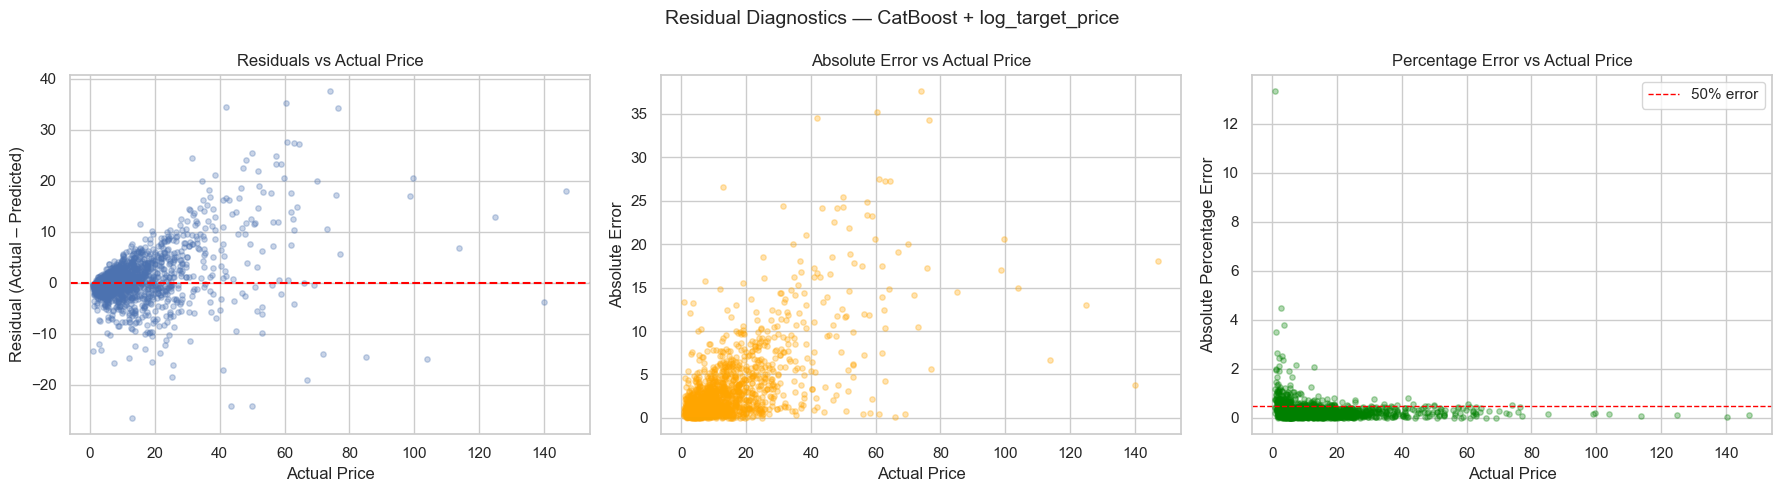

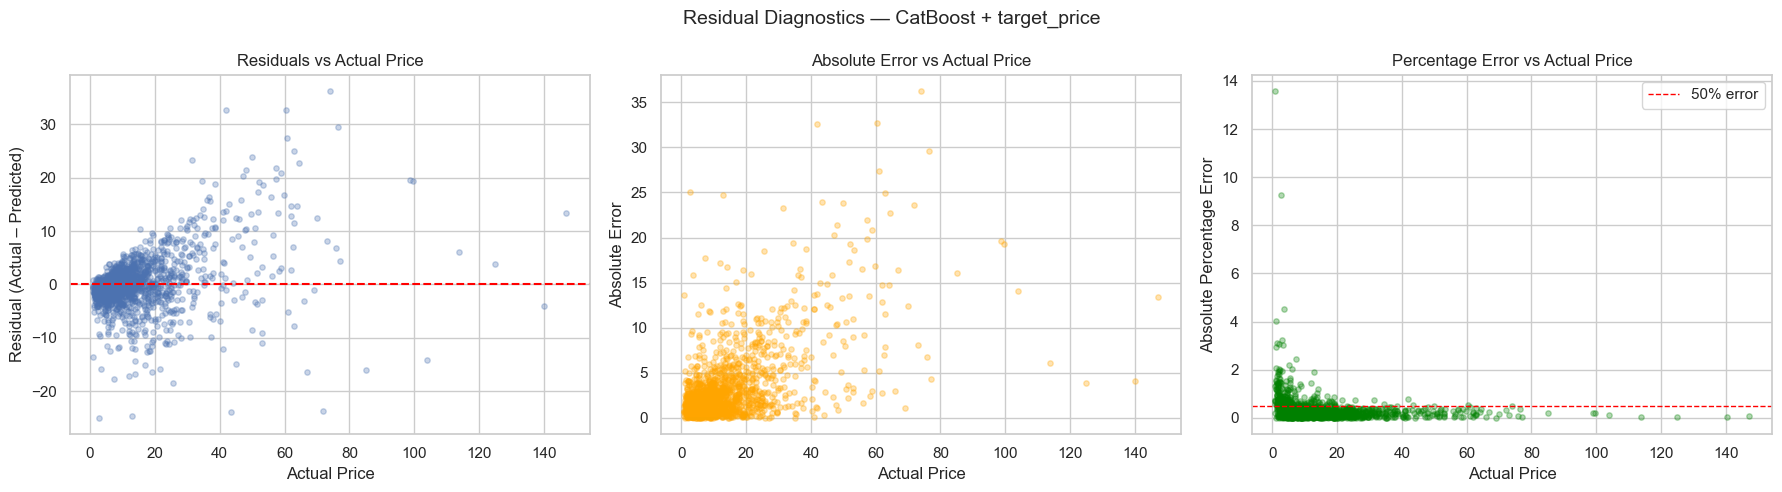

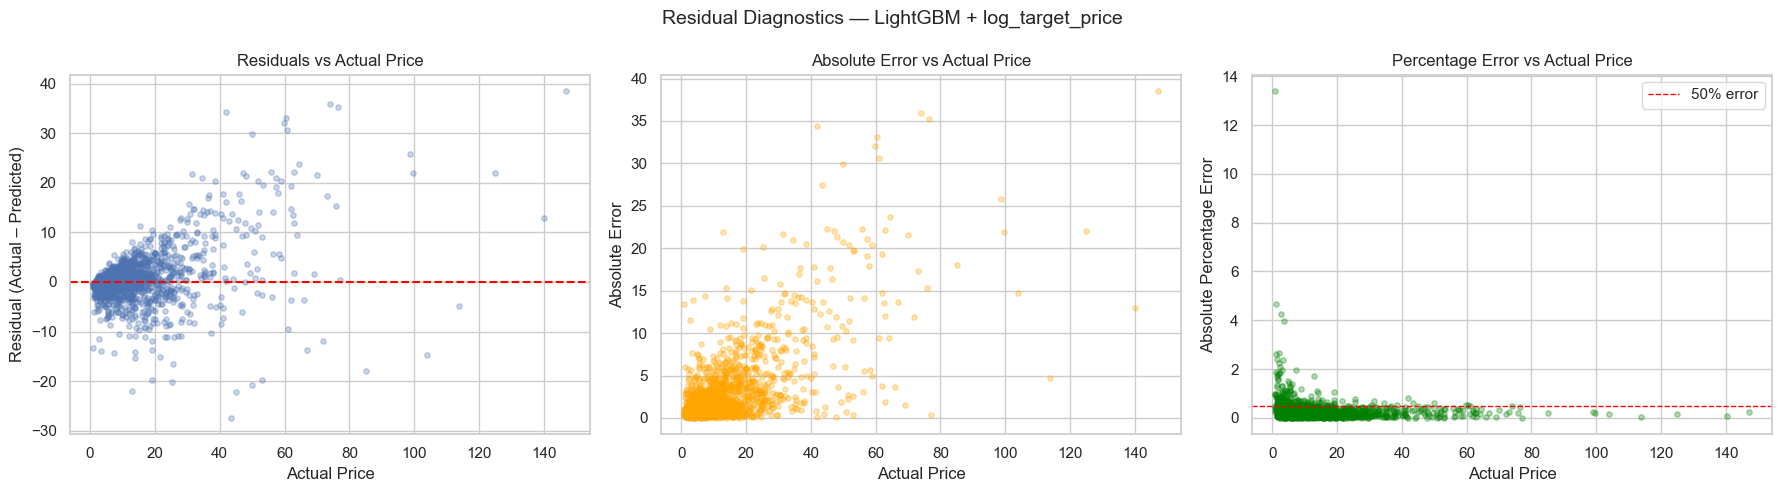

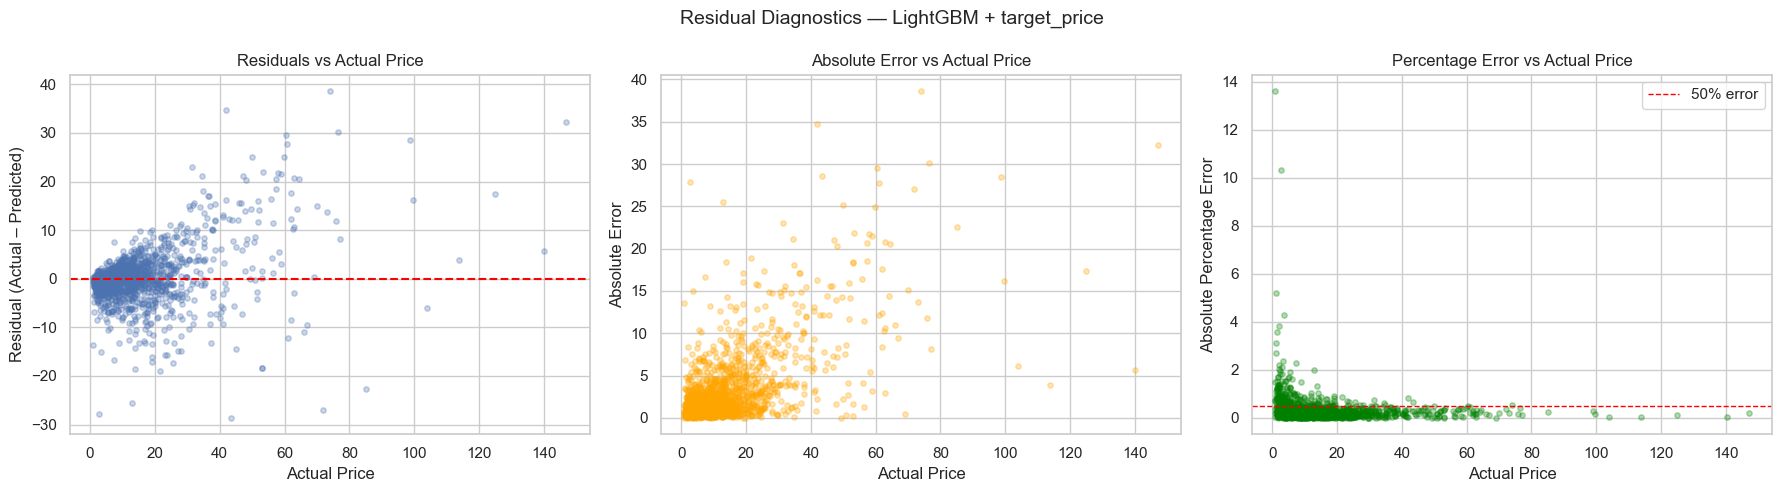

In [13]:
def plot_heteroscedasticity(diag_df, model_name, target_used, save_dir):
    """Three residual scatter plots for one model variant."""
    mask  = (diag_df['model_name'] == model_name) & (diag_df['target_used'] == target_used)
    grp   = diag_df[mask]
    label = f'{model_name} + {target_used}'
    fn    = safe_filename(model_name, target_used)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Residual Diagnostics — {label}', fontsize=14)

    axes[0].scatter(grp['actual_price'], grp['residual'], alpha=0.3, s=15)
    axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Residual (Actual – Predicted)')
    axes[0].set_title('Residuals vs Actual Price')

    axes[1].scatter(grp['actual_price'], grp['absolute_error'], alpha=0.3, s=15, color='orange')
    axes[1].set_xlabel('Actual Price')
    axes[1].set_ylabel('Absolute Error')
    axes[1].set_title('Absolute Error vs Actual Price')

    axes[2].scatter(grp['actual_price'], grp['absolute_percentage_error'], alpha=0.3, s=15, color='green')
    axes[2].axhline(0.5, color='red', linewidth=1, linestyle='--', label='50% error')
    axes[2].set_xlabel('Actual Price')
    axes[2].set_ylabel('Absolute Percentage Error')
    axes[2].set_title('Percentage Error vs Actual Price')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(save_dir / f'heteroscedasticity_{fn}.png', dpi=150, bbox_inches='tight')
    plt.show()


for model_name, target_used in available_model_targets:
    plot_heteroscedasticity(diag_df, model_name, target_used, DIAGNOSTICS_DIR)

### Interpretation - Residual Diagnostics

Across all evaluated model-target combinations, residuals are generally centered around zero, which supports the earlier finding that there is no strong global directional bias. However, the residual spread increases as actual price increases. This indicates heteroscedasticity: the models are less stable for higher-price listings than for lower-price listings.

The absolute error plots show that larger absolute errors mostly occur in the mid-to-high and premium price ranges. This means global metrics such as MAE and RMSE may hide important segment-level weaknesses, especially for expensive listings.

The percentage error plots show many extreme relative errors among very low-price listings. This is expected because small actual prices make percentage errors unstable: even a small absolute error can become a very large percentage error. Therefore, MAPE should be interpreted carefully and should not be the only criterion for model selection.

Overall, these diagnostics suggest two main issues:
1. High-price listings require better calibration because absolute errors become larger.
2. Low-price listings require careful interpretation because percentage errors can look extreme even when absolute errors are small.

For the next tuning notebook, model selection should combine global metrics with segment-level metrics, especially Premium-segment RMSE/underprediction and Low-price MAPE/extreme-error rate.

In [14]:
# Binned residual variance table
het_rows = []
for (model_name, target_used), grp in diag_df.groupby(["model_name", "target_used"], observed=True):
    grp = grp.copy()
    grp["price_bin"] = pd.qcut(grp["actual_price"], q=10, duplicates="drop")
    for bin_label, bin_grp in grp.groupby("price_bin", observed=True):
        metrics = compute_error_metrics(bin_grp["actual_price"], bin_grp["predicted_price"], bin_grp["residual"])
        het_rows.append({
            "model_name": model_name,
            "target_used": target_used,
            "price_bin": str(bin_label),
            "price_min": bin_grp["actual_price"].min(),
            "price_max": bin_grp["actual_price"].max(),
            "count": len(bin_grp),
            "residual_std": bin_grp["residual"].std(),
            "absolute_error_mean": bin_grp["absolute_error"].mean(),
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
        })
het_df = pd.DataFrame(het_rows)
het_df.to_csv(DIAGNOSTICS_DIR / "heteroscedasticity_binned_error_summary.csv", index=False)

for model_name in SELECTED_MODELS:
    if (model_name, PRIMARY_TARGET) not in available_model_targets:
        continue
    print(f"=== Binned Residual Variance - {model_name} + {PRIMARY_TARGET} ===")
    display(het_df[(het_df["model_name"] == model_name) & (het_df["target_used"] == PRIMARY_TARGET)][["price_bin", "price_min", "price_max", "count", "residual_std", "absolute_error_mean", "rmse", "mape"]])
    print()


=== Binned Residual Variance - CatBoost + log_target_price ===


,price_bin,price_min,price_max,count,residual_std,absolute_error_mean,rmse,mape
0,"(0.999, 3.2]",1.0000,3.2000,152,1.9120,1.3593,2.2420,0.7061
1,"(3.2, 4.91]",3.2490,4.9000,137,1.7524,1.3782,2.0130,0.3404
2,"(4.91, 6.5]",4.9500,6.5000,147,2.2369,1.5100,2.3107,0.2656
3,"(6.5, 8.44]",6.6000,8.4000,141,2.5633,1.8386,2.5542,0.2484
4,"(8.44, 10.7]",8.4990,10.7000,145,2.8884,2.2953,2.8796,0.2429
5,"(10.7, 13.49]",10.8000,13.4900,145,4.1472,2.8255,4.1329,0.2323
6,"(13.49, 16.891]",13.5000,16.8700,142,4.0824,3.1494,4.0931,0.2113
7,"(16.891, 21.997]",16.9000,21.9900,144,4.7117,3.7378,4.7168,0.1966
8,"(21.997, 31.43]",21.9990,30.8900,144,6.0309,5.1549,6.3242,0.2001
9,"(31.43, 146.99]",31.4900,146.9900,145,11.3307,11.1829,13.8664,0.2346



=== Binned Residual Variance - LightGBM + log_target_price ===


,price_bin,price_min,price_max,count,residual_std,absolute_error_mean,rmse,mape
20,"(0.999, 3.2]",1.0000,3.2000,152,2.0072,1.3799,2.3011,0.7116
21,"(3.2, 4.91]",3.2490,4.9000,137,1.8610,1.4180,2.0841,0.3513
22,"(4.91, 6.5]",4.9500,6.5000,147,2.2245,1.5391,2.2956,0.2710
23,"(6.5, 8.44]",6.6000,8.4000,141,2.4313,1.7642,2.4230,0.2389
24,"(8.44, 10.7]",8.4990,10.7000,145,2.8304,2.2053,2.8293,0.2338
25,"(10.7, 13.49]",10.8000,13.4900,145,3.7702,2.7178,3.7572,0.2241
26,"(13.49, 16.891]",13.5000,16.8700,142,4.3365,3.2085,4.3220,0.2153
27,"(16.891, 21.997]",16.9000,21.9900,144,4.9542,3.7734,4.9397,0.1988
28,"(21.997, 31.43]",21.9990,30.8900,144,6.2093,5.0075,6.3317,0.1952
29,"(31.43, 146.99]",31.4900,146.9900,145,12.0451,11.3375,14.3232,0.2316


### Interpretation - Binned Residual Variance

The binned residual variance analysis confirms heteroscedasticity. As actual price increases, the residual standard deviation, mean absolute error, and RMSE increase substantially for both CatBoost and LightGBM under the log-target setup.

For CatBoost + log_target_price, RMSE rises from around 2.23 in the lowest price bin to around 13.92 in the highest price bin. A similar pattern appears for LightGBM + log_target_price, where RMSE increases from around 2.36 to around 14.20. This indicates that prediction errors become much less stable for high-price listings.

Interestingly, MAPE generally decreases from low-price bins to mid/high-price bins. This suggests that percentage error is inflated for very low-price listings because small absolute errors become large relative errors. Therefore, RMSE and MAE are more informative for high-price diagnostics, while MAPE should be interpreted carefully for low-price listings.

Overall, this section provides strong evidence that future tuning should use segment-aware evaluation rather than relying only on global metrics. In particular, the next notebook should track high-price RMSE/MAE and low-price MAPE/extreme-error rate separately.

In [15]:
# Spearman correlation tests
hetero_evidence = []
for model_name in SELECTED_MODELS:
    main_grp = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == PRIMARY_TARGET)]
    if main_grp.empty:
        continue
    print(f"=== Correlation: Actual Price vs Error Magnitude ({model_name} + {PRIMARY_TARGET}) ===")
    r_main, p_main = np.nan, np.nan
    for err_col in ["absolute_error", "squared_error"]:
        r, p = stats.spearmanr(main_grp["actual_price"], main_grp[err_col])
        print(f"  actual_price vs {err_col}: rho={r:.3f}, p={p:.4f}")
        if err_col == "absolute_error":
            r_main, p_main = r, p
    flag = bool(r_main > 0.3 and p_main < 0.05)
    hetero_evidence.append({"model_name": model_name, "rho_abs_error": r_main, "p_value": p_main, "heteroscedasticity_flag": flag})
    if flag:
        print("  Positive correlation detected: heteroscedasticity is likely present.")
        print("  Next tuning should use segment-aware evaluation or sample weighting.")
    else:
        print("  No strong correlation between actual price and absolute error.")
    print()
hetero_evidence_df = pd.DataFrame(hetero_evidence)
hetero_evidence_df.to_csv(DIAGNOSTICS_DIR / "heteroscedasticity_correlation_tests.csv", index=False)


=== Correlation: Actual Price vs Error Magnitude (CatBoost + log_target_price) ===
  actual_price vs absolute_error: rho=0.536, p=0.0000
  actual_price vs squared_error: rho=0.536, p=0.0000
  Positive correlation detected: heteroscedasticity is likely present.
  Next tuning should use segment-aware evaluation or sample weighting.

=== Correlation: Actual Price vs Error Magnitude (LightGBM + log_target_price) ===
  actual_price vs absolute_error: rho=0.521, p=0.0000
  actual_price vs squared_error: rho=0.521, p=0.0000
  Positive correlation detected: heteroscedasticity is likely present.
  Next tuning should use segment-aware evaluation or sample weighting.



### Interpretation - Correlation Between Actual Price and Error Magnitude

The Spearman correlation results provide quantitative evidence of heteroscedasticity. For both CatBoost + log_target_price and LightGBM + log_target_price, actual price has a moderate positive correlation with absolute error and squared error.

CatBoost shows a correlation of approximately 0.534, while LightGBM shows a similar correlation of approximately 0.529. Both p-values are effectively 0, indicating that the relationship is statistically significant.

This means that as actual price increases, prediction error magnitude also tends to increase. Therefore, the models are not equally stable across the full price range. They perform more consistently on lower and mid-price listings, but become less reliable for high-price listings.

For the next tuning notebook, model evaluation should include segment-aware metrics. In particular, high-price RMSE/MAE should be monitored separately, and sample weighting or segment-specific calibration should be considered.

## 6. Price Segment Bias Analysis

Error metrics và bias indicators cho từng price segment (Low / Mid / High / Premium).

- **Negative mean residual** (actual − predicted < 0): model *overpredicts* ở segment đó
- **Positive mean residual**: model *underpredicts*
- **prediction_ratio > 1**: model predict cao hơn actual (overprediction)

In [16]:
seg_rows = []
for (model_name, target_used, segment), grp in diag_df.groupby(["model_name", "target_used", "price_segment"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    seg_rows.append({
        "model_name": model_name,
        "target_used": target_used,
        "price_segment": segment,
        "count": len(grp),
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "median_absolute_error": metrics["median_absolute_error"],
        "mean_residual": metrics["mean_residual"],
        "median_residual": metrics["median_residual"],
        "underprediction_rate": metrics["underprediction_rate"],
        "overprediction_rate": metrics["overprediction_rate"],
        "prediction_ratio_mean": grp["prediction_ratio"].mean(),
        "prediction_ratio_median": grp["prediction_ratio"].median(),
    })
seg_df = pd.DataFrame(seg_rows)
seg_df.to_csv(DIAGNOSTICS_DIR / "price_segment_bias_summary.csv", index=False)
for model_name in SELECTED_MODELS:
    model_seg = seg_df[seg_df["model_name"] == model_name]
    if model_seg.empty:
        continue
    print(f"=== Segment Bias Summary - {model_name} ===")
    display(model_seg[["model_name", "target_used", "price_segment", "count", "mae", "rmse", "mape", "mean_residual", "underprediction_rate", "overprediction_rate", "prediction_ratio_mean"]])
    print()


=== Segment Bias Summary - CatBoost ===


,model_name,target_used,price_segment,count,mae,rmse,mape,mean_residual,underprediction_rate,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,Low,369,1.4321,2.2160,0.4843,-1.0483,0.2602,0.7398,1.3915
1,CatBoost,log_target_price,Mid,353,1.9292,2.6152,0.2395,-0.0254,0.5609,0.4391,1.0071
2,CatBoost,log_target_price,High,361,3.1289,4.2021,0.2187,0.2439,0.5873,0.4127,0.9845
3,CatBoost,log_target_price,Premium,359,7.3244,9.9195,0.2114,4.1500,0.6685,0.3315,0.8956
4,CatBoost,target_price,Low,369,1.8119,2.9169,0.6204,-1.5013,0.2114,0.7886,1.5382
5,CatBoost,target_price,Mid,353,2.1213,2.9079,0.2662,-0.3633,0.5042,0.4958,1.0495
6,CatBoost,target_price,High,361,3.2749,4.5406,0.2292,-0.3589,0.5457,0.4543,1.0262
7,CatBoost,target_price,Premium,359,6.6985,9.0977,0.1961,3.0762,0.6407,0.3593,0.9277



=== Segment Bias Summary - LightGBM ===


,model_name,target_used,price_segment,count,mae,rmse,mape,mean_residual,underprediction_rate,overprediction_rate,prediction_ratio_mean
8,LightGBM,log_target_price,Low,369,1.4664,2.2759,0.4927,-1.0175,0.2981,0.7019,1.3799
9,LightGBM,log_target_price,Mid,353,1.8631,2.5257,0.2320,0.0293,0.5694,0.4306,1.0015
10,LightGBM,log_target_price,High,361,3.1152,4.2001,0.2173,0.0730,0.5651,0.4349,0.9955
11,LightGBM,log_target_price,Premium,359,7.3356,10.2020,0.2088,3.7262,0.6769,0.3231,0.9131
12,LightGBM,target_price,Low,369,1.7568,2.9038,0.5949,-1.3765,0.2520,0.7480,1.4852
13,LightGBM,target_price,Mid,353,1.9623,2.7673,0.2457,-0.2794,0.5382,0.4618,1.0408
14,LightGBM,target_price,High,361,3.2228,4.5118,0.2246,-0.4567,0.5208,0.4792,1.0316
15,LightGBM,target_price,Premium,359,7.1907,9.8331,0.2064,2.8471,0.6045,0.3955,0.9407


### Interpretation - Segment Bias Summary

The segment-level diagnostics reveal clear price-dependent bias that is not visible from global metrics alone.

For the Low-price segment, all model-target combinations tend to overpredict. The overprediction rate is around 70%–80%, and the prediction ratio mean is well above 1.0. This means predicted prices are often higher than actual prices for cheaper listings. The issue is strongest for the raw `target_price` models, where the prediction ratio mean reaches about 1.53 for CatBoost and 1.48 for LightGBM.

For the Premium segment, the opposite pattern appears. All models tend to underpredict expensive listings. The underprediction rate is around 60%–67%, and the prediction ratio mean is below 1.0. This indicates that high-price listings are systematically predicted too low. The issue is strongest for log-target models, especially CatBoost + log_target_price, where the prediction ratio mean is about 0.90 and the underprediction rate is about 67%.

Mid and High segments are much more balanced, with prediction ratio means close to 1.0 and smaller mean residuals. This suggests that the main model weakness is not overall bias, but tail-segment bias at both ends of the price distribution.

For the next tuning notebook, evaluation should prioritize segment-aware metrics. In particular, Low-price overprediction and Premium-price underprediction should be monitored separately. Potential next steps include segment-specific calibration, sample weighting for premium listings, or testing whether raw target models reduce premium compression compared with log-target models.

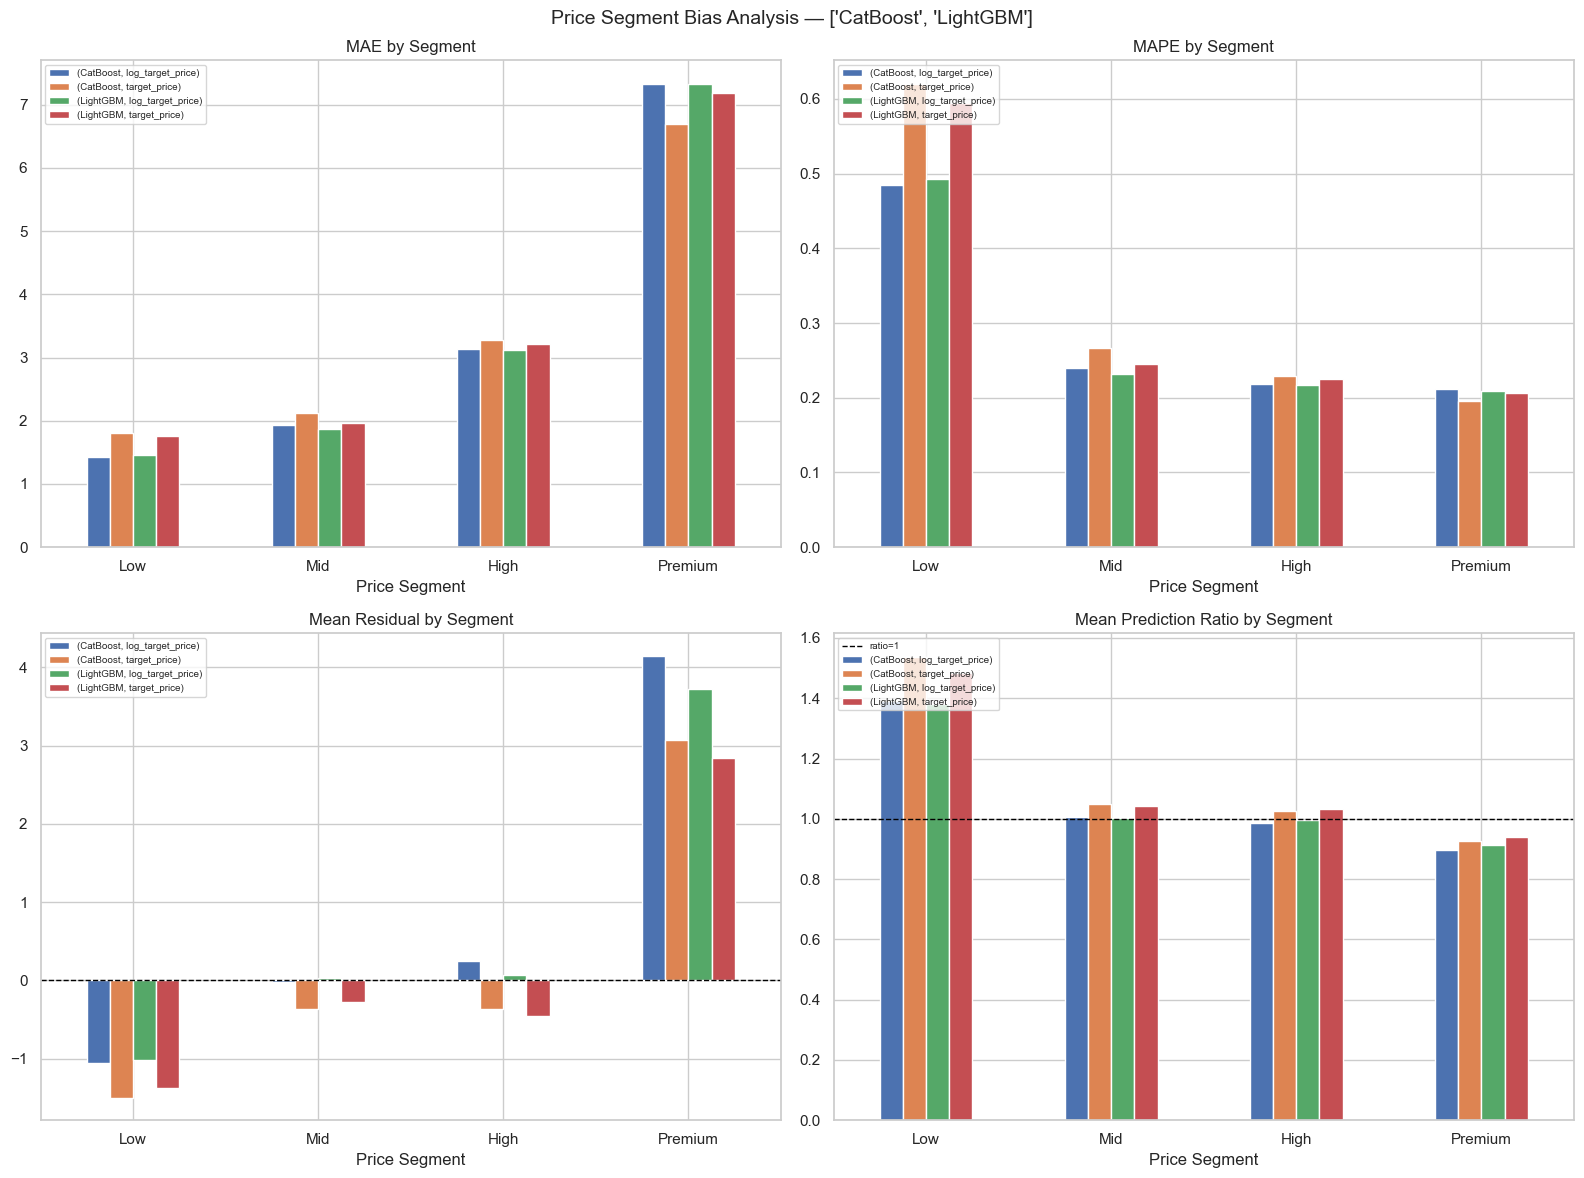

In [17]:
# ── Segment bias plots ─────────────────────────────────────────────────────────
segments_order = ['Low', 'Mid', 'High', 'Premium']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Price Segment Bias Analysis — {SELECTED_MODELS}', fontsize=14)

for ax, metric, title in zip(
    axes.flatten(),
    ['mae', 'mape', 'mean_residual', 'prediction_ratio_mean'],
    ['MAE by Segment', 'MAPE by Segment', 'Mean Residual by Segment', 'Mean Prediction Ratio by Segment'],
):
    pivot = seg_df.pivot_table(index='price_segment', columns=['model_name', 'target_used'], values=metric)
    pivot = pivot.reindex(segments_order)
    pivot.plot(kind='bar', ax=ax, legend=True)
    if metric == 'mean_residual':
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
    if metric == 'prediction_ratio_mean':
        ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='ratio=1')
    ax.set_title(title)
    ax.set_xlabel('Price Segment')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / 'price_segment_bias_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation - Price Segment Bias Analysis

The segment-level plots confirm that model errors are not evenly distributed across price ranges.

MAE increases sharply from Low to Premium segments, showing that absolute prediction errors become larger for more expensive listings. This is expected to some extent because high-price listings have larger price scale, but the increase is large enough to suggest weaker model stability in the Premium segment.

MAPE shows the opposite pattern: it is highest in the Low-price segment and lower in Mid, High, and Premium segments. This happens because percentage error is very sensitive when actual prices are small. Therefore, Low-segment MAPE should be interpreted carefully and should be paired with absolute-error metrics.

The mean residual and prediction ratio plots show clear directional bias. Low-price listings are generally overpredicted, with prediction ratios far above 1.0. Premium listings are generally underpredicted, with prediction ratios below 1.0 and positive mean residuals. Mid and High segments are more balanced, with prediction ratios closer to 1.0.

Overall, the main issue is not global bias, but tail-segment bias: the models overestimate low-price listings and underestimate premium listings. The next tuning notebook should therefore evaluate models using segment-aware metrics and consider calibration or weighting strategies for the Low and Premium segments.

In [18]:
# Segment bias interpretation
for model_name in SELECTED_MODELS:
    for target_used in ANALYZED_TARGETS:
        mask = (seg_df["model_name"] == model_name) & (seg_df["target_used"] == target_used)
        s = seg_df[mask].set_index("price_segment")
        if s.empty:
            continue
        print(f"=== {model_name} + {target_used} - Segment Interpretation ===")
        for seg in ["Low", "Premium"]:
            if seg not in s.index:
                continue
            row = s.loc[seg]
            direction = "underpredicts" if row["mean_residual"] > 0 else "overpredicts"
            print(f"  {seg}: mean_residual={row['mean_residual']:,.0f} ({direction}); over_rate={row['overprediction_rate']:.1%}; under_rate={row['underprediction_rate']:.1%}")
        print()


=== CatBoost + log_target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=74.0%; under_rate=26.0%
  Premium: mean_residual=4 (underpredicts); over_rate=33.1%; under_rate=66.9%

=== CatBoost + target_price - Segment Interpretation ===
  Low: mean_residual=-2 (overpredicts); over_rate=78.9%; under_rate=21.1%
  Premium: mean_residual=3 (underpredicts); over_rate=35.9%; under_rate=64.1%

=== LightGBM + log_target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=70.2%; under_rate=29.8%
  Premium: mean_residual=4 (underpredicts); over_rate=32.3%; under_rate=67.7%

=== LightGBM + target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=74.8%; under_rate=25.2%
  Premium: mean_residual=3 (underpredicts); over_rate=39.6%; under_rate=60.4%



### Interpretation - Low vs Premium Segment Directional Bias

The segment interpretation confirms a consistent directional bias across all model-target combinations. Low-price listings are systematically overpredicted, while Premium listings are systematically underpredicted.

For the Low segment, overprediction rates range from about 69.9% to 79.9%. This means the models usually predict prices that are too high for cheaper listings. The strongest Low-segment overprediction appears in CatBoost + target_price.

For the Premium segment, underprediction rates range from about 60.4% to 67.4%. This means the models usually predict prices that are too low for expensive listings. The strongest Premium underprediction appears in CatBoost + log_target_price.

This pattern suggests that the models compress predictions toward the middle of the price distribution: low prices are pushed upward and premium prices are pulled downward. Therefore, future tuning should not rely only on global metrics. It should include segment-aware validation and consider calibration or weighting strategies for the Low and Premium segments.

## 7. Premium Segment Deep Dive

Tập trung vào laptops thuộc Premium segment (actual price > Q75) để hiểu underprediction pattern. Primary model là model đầu tiên trong `SELECTED_MODELS` với `log_target_price`; so sánh với cùng model dùng `target_price`.

In [19]:
premium_mask = diag_df['price_segment'] == 'Premium'
premium_df   = diag_df[premium_mask].copy()

print('=== Premium Segment — Summary (SELECTED_MODELS) ===')
prem_rows = []
for (model_name, target_used), grp in premium_df.groupby(['model_name', 'target_used'], observed=True):
    yt  = grp['actual_price'].values
    yp  = grp['predicted_price'].values
    res = grp['residual'].values
    prem_rows.append({
        'model_name':            model_name,
        'target_used':           target_used,
        'count':                 len(yt),
        'mae':                   mean_absolute_error(yt, yp),
        'rmse':                  root_mean_squared_error(yt, yp),
        'mape':                  mean_absolute_percentage_error(yt, yp),
        'mean_residual':         res.mean(),
        'underprediction_rate':  (res > 0).mean(),
        'prediction_ratio_mean': grp['prediction_ratio'].mean(),
        'prediction_ratio_median': grp['prediction_ratio'].median(),
    })

prem_summary = pd.DataFrame(prem_rows)
prem_summary.to_csv(DIAGNOSTICS_DIR / 'premium_segment_diagnostics.csv', index=False)
display(prem_summary)

=== Premium Segment — Summary (SELECTED_MODELS) ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,underprediction_rate,prediction_ratio_mean,prediction_ratio_median
0,CatBoost,log_target_price,359,7.3244,9.9195,0.2114,4.1500,0.6685,0.8956,0.8773
1,CatBoost,target_price,359,6.6985,9.0977,0.1961,3.0762,0.6407,0.9277,0.9340
2,LightGBM,log_target_price,359,7.3356,10.2020,0.2088,3.7262,0.6769,0.9131,0.9083
3,LightGBM,target_price,359,7.1907,9.8331,0.2064,2.8471,0.6045,0.9407,0.9255


### Interpretation - Premium Segment

The Premium segment shows consistent underprediction across all evaluated model-target combinations. Underprediction rates range from about 60% to 67%, and both mean and median prediction ratios are below 1.0 for every model. This indicates that expensive listings are systematically predicted lower than their actual prices.

Among the evaluated combinations, **CatBoost + target_price** has the lowest Premium RMSE (9.22) and lowest Premium MAPE (19.8%). It also has a higher prediction ratio mean (0.928) than CatBoost + log_target_price (0.896), suggesting that the raw target setup reduces premium compression compared with the log-target setup.

However, all models still underpredict Premium listings, so this is not fully solved by switching target transformations. The next tuning notebook should monitor Premium RMSE, Premium underprediction rate, and prediction ratio separately. Potential improvements include premium sample weighting, segment-specific calibration, or post-model correction validated on a separate validation set.

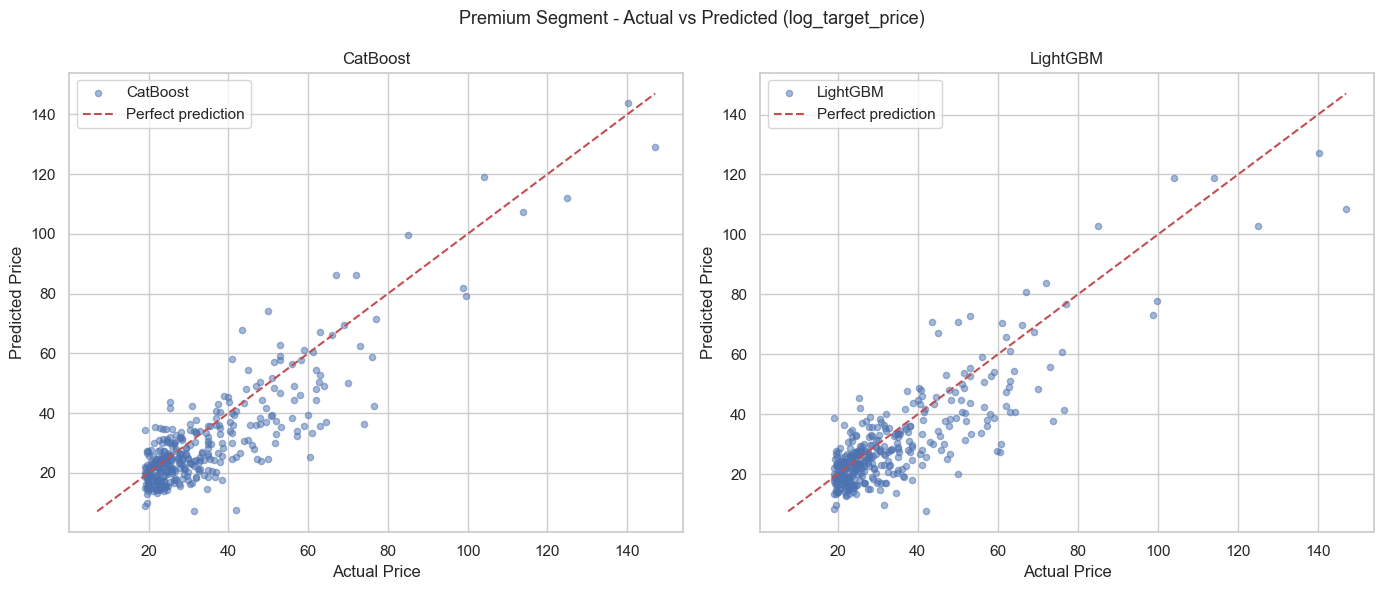

In [20]:
# Premium: actual vs predicted plots for available primary-target models
plot_models = [m for m in SELECTED_MODELS if (m, PRIMARY_TARGET) in available_model_targets]
n_models = len(plot_models)
fig, axes = plt.subplots(1, n_models, figsize=(7 * max(n_models, 1), 6))
if n_models == 1:
    axes = [axes]
fig.suptitle(f"Premium Segment - Actual vs Predicted ({PRIMARY_TARGET})", fontsize=13)

for ax, model_name in zip(axes, plot_models):
    grp = premium_df[(premium_df["model_name"] == model_name) & (premium_df["target_used"] == PRIMARY_TARGET)]
    ax.scatter(grp["actual_price"], grp["predicted_price"], alpha=0.5, s=20, label=model_name)
    lim_min = min(grp["actual_price"].min(), grp["predicted_price"].min())
    lim_max = max(grp["actual_price"].max(), grp["predicted_price"].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_title(model_name)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.legend()

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "premium_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretation - Premium Actual vs Predicted

The Premium actual-vs-predicted plots show that both CatBoost and LightGBM tend to underpredict high-price listings under the log-target setup. Many observations in the higher actual-price range fall below the perfect prediction line, meaning predicted prices are lower than actual prices.

This visual pattern supports the Premium Segment Summary, where both models have prediction ratio means and medians below 1.0 and underprediction rates above 60%. The result suggests prediction compression: the models pull expensive listings toward more moderate predicted prices instead of fully capturing the upper tail of the price distribution.

For the next tuning notebook, Premium-segment performance should be evaluated separately using RMSE, MAE, underprediction rate, and prediction ratio. Potential improvements include premium sample weighting, segment-specific calibration, or comparing log-target models against raw-target models for high-price listings.

In [21]:
# Premium: top error cases for primary pair
main_premium = premium_df[(premium_df["model_name"] == PRIMARY_MODEL) & (premium_df["target_used"] == PRIMARY_TARGET)].copy()
top20_premium = main_premium.nlargest(20, "absolute_error")
top20_premium.to_csv(DIAGNOSTICS_DIR / "premium_top_error_cases.csv", index=False)
print(f"=== Top 20 Premium Error Cases ({PRIMARY_MODEL} + {PRIMARY_TARGET}) ===")
display(top20_premium[["sample_id", "actual_price", "predicted_price", "residual", "absolute_error", "absolute_percentage_error"]].head(20))


=== Top 20 Premium Error Cases (CatBoost + log_target_price) ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error
944,6544,73.9000,36.3062,37.5938,37.5938,0.5087
341,6148,60.4900,25.2651,35.2249,35.2249,0.5823
1106,3274,42.0000,7.5580,34.4420,34.4420,0.8200
1369,5721,76.5000,42.2723,34.2277,34.2277,0.4474
1332,5396,60.9000,33.3980,27.5020,27.5020,0.4516
189,5345,62.9900,35.6912,27.2988,27.2988,0.4334
1153,6970,64.3900,37.1908,27.1992,27.1992,0.4224
1298,6740,50.0489,24.6084,25.4405,25.4405,0.5083
843,5767,57.2900,32.4263,24.8637,24.8637,0.4340
36,2182,31.5000,7.1112,24.3888,24.3888,0.7742


### Interpretation - Top Premium Error Cases

The largest Premium-segment errors for CatBoost + log_target_price are mostly underpredictions. Many high-price listings are predicted far below their actual values, with absolute errors above 20–35 price units and percentage errors often above 40%.

This supports the earlier Premium diagnostics: the model tends to compress high-price listings downward instead of fully capturing the upper tail of the price distribution. Although a few large errors are overpredictions, the dominant pattern among the worst Premium cases is underprediction.

These cases should be inspected further in the original feature data. Potential causes may include rare high-value product attributes, sparse premium examples, missing feature interactions, or outlier-like listings. The next tuning notebook should test Premium-aware validation, sample weighting, and segment-specific calibration.

## 8. Low-Price Segment Deep Dive

Low-price laptops (actual price ≤ Q25) có thể bị overpredict do mean-reversion effects trong tree models.

In [22]:
low_mask = diag_df["price_segment"] == "Low"
low_df = diag_df[low_mask].copy()

print("=== Low-Price Segment Summary ===")
low_rows = []
for (model_name, target_used), grp in low_df.groupby(["model_name", "target_used"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    low_rows.append({
        "model_name": model_name,
        "target_used": target_used,
        "count": len(grp),
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "mean_residual": metrics["mean_residual"],
        "overprediction_rate": metrics["overprediction_rate"],
        "prediction_ratio_mean": grp["prediction_ratio"].mean(),
    })
low_summary = pd.DataFrame(low_rows)
low_summary.to_csv(DIAGNOSTICS_DIR / "low_price_segment_diagnostics.csv", index=False)
display(low_summary)


=== Low-Price Segment Summary ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,369,1.4321,2.2160,0.4843,-1.0483,0.7398,1.3915
1,CatBoost,target_price,369,1.8119,2.9169,0.6204,-1.5013,0.7886,1.5382
2,LightGBM,log_target_price,369,1.4664,2.2759,0.4927,-1.0175,0.7019,1.3799
3,LightGBM,target_price,369,1.7568,2.9038,0.5949,-1.3765,0.7480,1.4852


### Interpretation - Low-Price Segment

The Low-price segment shows consistent overprediction across all evaluated model-target combinations. Mean residuals are negative for every model, overprediction rates are high, and prediction ratio means are well above 1.0.

This means the models often predict prices that are too high for cheaper listings. The issue is strongest for the raw `target_price` setup, where CatBoost reaches an overprediction rate of about 79.9% and a prediction ratio mean of about 1.53. LightGBM + target_price shows a similar pattern with a prediction ratio mean of about 1.48.

Compared with raw-target models, log-target models reduce Low-segment overprediction slightly, but the bias is still substantial. Therefore, the Low segment should be monitored separately in the next tuning notebook using MAPE, overprediction rate, and prediction ratio.

Potential next steps include segment-specific calibration, clipping unrealistic low-price predictions, or using custom sample weights to reduce systematic overestimation in the Low segment.

In [23]:
# Low-price: top overpredicted cases for primary pair
main_low = low_df[(low_df["model_name"] == PRIMARY_MODEL) & (low_df["target_used"] == PRIMARY_TARGET)].copy()
top_low_over = main_low[main_low["residual"] < 0].nsmallest(20, "residual")
top_low_over.to_csv(DIAGNOSTICS_DIR / "low_price_top_error_cases.csv", index=False)
print("=== Top 20 Overpredicted Low-Price Cases ===")
display(top_low_over[["sample_id", "actual_price", "predicted_price", "residual", "absolute_percentage_error"]].head(20))

over_rate = (main_low["residual"] < 0).mean() if len(main_low) else np.nan
print(f"\nOverprediction rate for Low-price segment ({PRIMARY_MODEL} + {PRIMARY_TARGET}): {over_rate:.1%}")
if over_rate > 0.55:
    print("Model tends to overpredict low-price laptops, consistent with mean-reversion.")
else:
    print("No strong overprediction bias in the low-price segment for the primary pair.")


=== Top 20 Overpredicted Low-Price Cases ===


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error
587,696,1.0000,14.3303,-13.3303,13.3303
812,3647,3.5000,16.7219,-13.2219,3.7777
369,2299,2.7000,14.7676,-12.0676,4.4695
867,3817,5.2000,15.1646,-9.9646,1.9163
299,4557,3.2000,10.7862,-7.5862,2.3707
671,2155,2.8890,10.1898,-7.3008,2.5271
1015,5723,5.5000,12.7863,-7.2863,1.3248
1276,5617,5.5000,12.1578,-6.6578,1.2105
904,3169,2.2000,7.5937,-5.3937,2.4517
468,3235,5.5000,10.7814,-5.2814,0.9603



Overprediction rate for Low-price segment (CatBoost + log_target_price): 74.0%
Model tends to overpredict low-price laptops, consistent with mean-reversion.


### Interpretation - Top Overpredicted Low-Price Cases

The top Low-price error cases confirm systematic overprediction in the lower tail of the price distribution. All listed cases have negative residuals, meaning the predicted price is higher than the actual price.

Several examples show very large relative errors because the actual prices are extremely small. For instance, a listing with an actual price of 1.00 is predicted at around 14.35, producing an absolute percentage error above 13. This explains why the Low segment has much higher MAPE than other segments.

This pattern suggests mean-reversion: the model pulls very low-price listings upward toward more common price levels instead of preserving the lower tail. The next tuning notebook should therefore monitor Low-segment MAPE, overprediction rate, and prediction ratio separately. Potential fixes include low-price calibration, segment-specific correction, or reviewing whether extremely low prices represent valid listings or data-quality issues.

## 9. Top Error Case Analysis

Xem xét các samples có lỗi lớn nhất để hiểu nguồn gốc sai số — từ price segment cụ thể hay từ data quality issues.

In [24]:
base_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual',
             'absolute_error', 'absolute_percentage_error', 'price_segment']

for model_name in SELECTED_MODELS:
    main_all = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()

    if main_all.empty:
        continue

    top_abs   = main_all.nlargest(30, 'absolute_error')
    top_pct   = main_all.nlargest(30, 'absolute_percentage_error')
    top_under = main_all.nlargest(30, 'residual')
    top_over  = main_all.nsmallest(30, 'residual')

    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    top_abs[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_absolute_error_{fn}.csv', index=False)
    top_pct[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_percentage_error_{fn}.csv', index=False)
    top_under[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_underpredicted_{fn}.csv', index=False)
    top_over[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_overpredicted_{fn}.csv', index=False)

    print(f'=== {model_name} — Top 10 by Absolute Error ===')
    display(top_abs[base_cols].head(10))

    print(f'\n=== {model_name} — Segment distribution in Top 30 Absolute Errors ===')
    print(top_abs['price_segment'].value_counts())
    print()

print('\nSaved: top_absolute_error_*, top_percentage_error_*, top_underpredicted_*, top_overpredicted_*')

=== CatBoost — Top 10 by Absolute Error ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,price_segment
944,6544,73.9000,36.3062,37.5938,37.5938,0.5087,Premium
341,6148,60.4900,25.2651,35.2249,35.2249,0.5823,Premium
1106,3274,42.0000,7.5580,34.4420,34.4420,0.8200,Premium
1369,5721,76.5000,42.2723,34.2277,34.2277,0.4474,Premium
1332,5396,60.9000,33.3980,27.5020,27.5020,0.4516,Premium
189,5345,62.9900,35.6912,27.2988,27.2988,0.4334,Premium
1153,6970,64.3900,37.1908,27.1992,27.1992,0.4224,Premium
634,6957,12.8900,39.4371,-26.5471,26.5471,2.0595,High
1298,6740,50.0489,24.6084,25.4405,25.4405,0.5083,Premium
843,5767,57.2900,32.4263,24.8637,24.8637,0.4340,Premium



=== CatBoost — Segment distribution in Top 30 Absolute Errors ===
price_segment
Premium    29
High        1
Low         0
Mid         0
Name: count, dtype: int64

=== LightGBM — Top 10 by Absolute Error ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,price_segment
3818,7067,146.9900,108.4586,38.5314,38.5314,0.2621,Premium
3828,6544,73.9000,37.9166,35.9834,35.9834,0.4869,Premium
4253,5721,76.5000,41.2789,35.2211,35.2211,0.4604,Premium
3990,3274,42.0000,7.6340,34.3660,34.3660,0.8182,Premium
3225,6148,60.4900,27.3433,33.1467,33.1467,0.5480,Premium
4097,6555,59.9000,27.8547,32.0453,32.0453,0.5350,Premium
4216,5396,60.9000,30.2581,30.6419,30.6419,0.5032,Premium
4182,6740,50.0489,20.1159,29.9330,29.9330,0.5981,Premium
3718,7175,43.5000,70.9220,-27.4220,27.4220,0.6304,Premium
3757,7199,98.8400,73.0569,25.7831,25.7831,0.2609,Premium



=== LightGBM — Segment distribution in Top 30 Absolute Errors ===
price_segment
Premium    29
High        1
Low         0
Mid         0
Name: count, dtype: int64


Saved: top_absolute_error_*, top_percentage_error_*, top_underpredicted_*, top_overpredicted_*


### Interpretation - Top Absolute Error Cases

The largest absolute errors are overwhelmingly concentrated in the Premium segment. For both CatBoost and LightGBM, 29 out of the top 30 absolute-error cases come from Premium listings, while only one comes from the High segment and none come from Low or Mid segments.

This confirms that the main source of large absolute prediction errors is the upper tail of the price distribution. Although Low-price listings have high percentage errors, they do not dominate the largest absolute-error cases. In contrast, Premium listings create the highest RMSE risk because their absolute errors are much larger.

The top-error tables also show that most of these Premium cases are underpredictions, where actual prices are much higher than predicted prices. This is consistent with the earlier Premium Segment Summary and actual-vs-predicted plots.

For the next tuning notebook, Premium-specific evaluation should be prioritized. The model should be selected not only by global RMSE or MAE, but also by Premium RMSE, Premium underprediction rate, and prediction ratio.

## 10. Log-Target Compression Check

So sánh `log_target_price` vs `target_price` theo price segment để phát hiện xem log-transform có nén prediction ở vùng giá cao không (prediction_ratio < 1 ở Premium).

In [25]:
for model_name in SELECTED_MODELS:
    log_col = f'pred_{safe_filename(model_name, "log_target_price")}'
    raw_col = f'pred_{safe_filename(model_name, "target_price")}'

    if log_col not in predictions_raw.columns or raw_col not in predictions_raw.columns:
        print(f'{model_name}: one or both target columns not found — skipping compression check.')
        continue

    actual   = predictions_raw[actual_col].values
    pred_log = predictions_raw[log_col].values
    pred_raw = predictions_raw[raw_col].values

    comp_df = pd.DataFrame({
        'actual_price':        actual,
        'pred_log':            pred_log,
        'pred_raw':            pred_raw,
        'residual_log':        actual - pred_log,
        'residual_raw':        actual - pred_raw,
        'prediction_ratio_log': pred_log / (actual + 1e-9),
        'prediction_ratio_raw': pred_raw / (actual + 1e-9),
    })
    comp_df['price_segment'] = comp_df['actual_price'].apply(assign_segment)
    comp_df['price_segment'] = pd.Categorical(
        comp_df['price_segment'], categories=['Low', 'Mid', 'High', 'Premium'], ordered=True
    )

    seg_comp = comp_df.groupby('price_segment', observed=True).agg(
        count=('actual_price', 'count'),
        pred_ratio_log_mean=('prediction_ratio_log', 'mean'),
        pred_ratio_raw_mean=('prediction_ratio_raw', 'mean'),
        residual_log_mean=('residual_log', 'mean'),
        residual_raw_mean=('residual_raw', 'mean'),
        underpred_log=('residual_log', lambda x: (x > 0).mean()),
        underpred_raw=('residual_raw', lambda x: (x > 0).mean()),
    ).reset_index()

    seg_comp.to_csv(DIAGNOSTICS_DIR / f'{MODEL_NAME_FOR_FILE.get(model_name, model_name)}_log_vs_raw_compression.csv', index=False)
    print(f'=== {model_name} — Log vs Raw Compression Check by Segment ===')
    display(seg_comp)

    # Interpretation
    if 'Premium' in seg_comp['price_segment'].values:
        prem = seg_comp[seg_comp['price_segment'] == 'Premium'].iloc[0]
        if prem['pred_ratio_log_mean'] < prem['pred_ratio_raw_mean']:
            print(f'Log-target has lower prediction ratio than raw-target in Premium segment.')
            print(f'    → Log-transform compresses high-price predictions — underprediction bias.')
        else:
            print(f'Log-target does not compress Premium predictions more than raw-target.')
    print()

=== CatBoost — Log vs Raw Compression Check by Segment ===


,price_segment,count,pred_ratio_log_mean,pred_ratio_raw_mean,residual_log_mean,residual_raw_mean,underpred_log,underpred_raw
0,Low,369,1.3915,1.5382,-1.0483,-1.5013,0.2602,0.2114
1,Mid,353,1.0071,1.0495,-0.0254,-0.3633,0.5609,0.5042
2,High,361,0.9845,1.0262,0.2439,-0.3589,0.5873,0.5457
3,Premium,359,0.8956,0.9277,4.1500,3.0762,0.6685,0.6407


Log-target has lower prediction ratio than raw-target in Premium segment.
    → Log-transform compresses high-price predictions — underprediction bias.

=== LightGBM — Log vs Raw Compression Check by Segment ===


,price_segment,count,pred_ratio_log_mean,pred_ratio_raw_mean,residual_log_mean,residual_raw_mean,underpred_log,underpred_raw
0,Low,369,1.3799,1.4852,-1.0175,-1.3765,0.2981,0.2520
1,Mid,353,1.0015,1.0408,0.0293,-0.2794,0.5694,0.5382
2,High,361,0.9955,1.0316,0.0730,-0.4567,0.5651,0.5208
3,Premium,359,0.9131,0.9407,3.7262,2.8471,0.6769,0.6045


Log-target has lower prediction ratio than raw-target in Premium segment.
    → Log-transform compresses high-price predictions — underprediction bias.



### Interpretation - Log vs Raw Target Compression

The log-vs-raw comparison shows that log-target models have lower Premium prediction ratios than raw-target models for both CatBoost and LightGBM. This supports the hypothesis that the log transformation compresses high-price predictions and contributes to Premium underprediction.

For CatBoost, the Premium prediction ratio is about 0.896 with the log target and 0.928 with the raw target. For LightGBM, the Premium prediction ratio is about 0.916 with the log target and 0.940 with the raw target. In both cases, raw-target models still underpredict Premium listings, but the underprediction is less severe.

This creates a trade-off. Log-target models improve relative error globally and reduce some extreme percentage errors, but they may worsen upper-tail compression. Raw-target models preserve Premium prices slightly better, but they can overpredict Low-price listings more strongly.

Therefore, the next tuning notebook should not choose the target transformation based only on global metrics. It should compare `log_target_price` and `target_price` using segment-aware validation, especially Premium prediction ratio, Premium underprediction rate, and Low-segment overprediction.

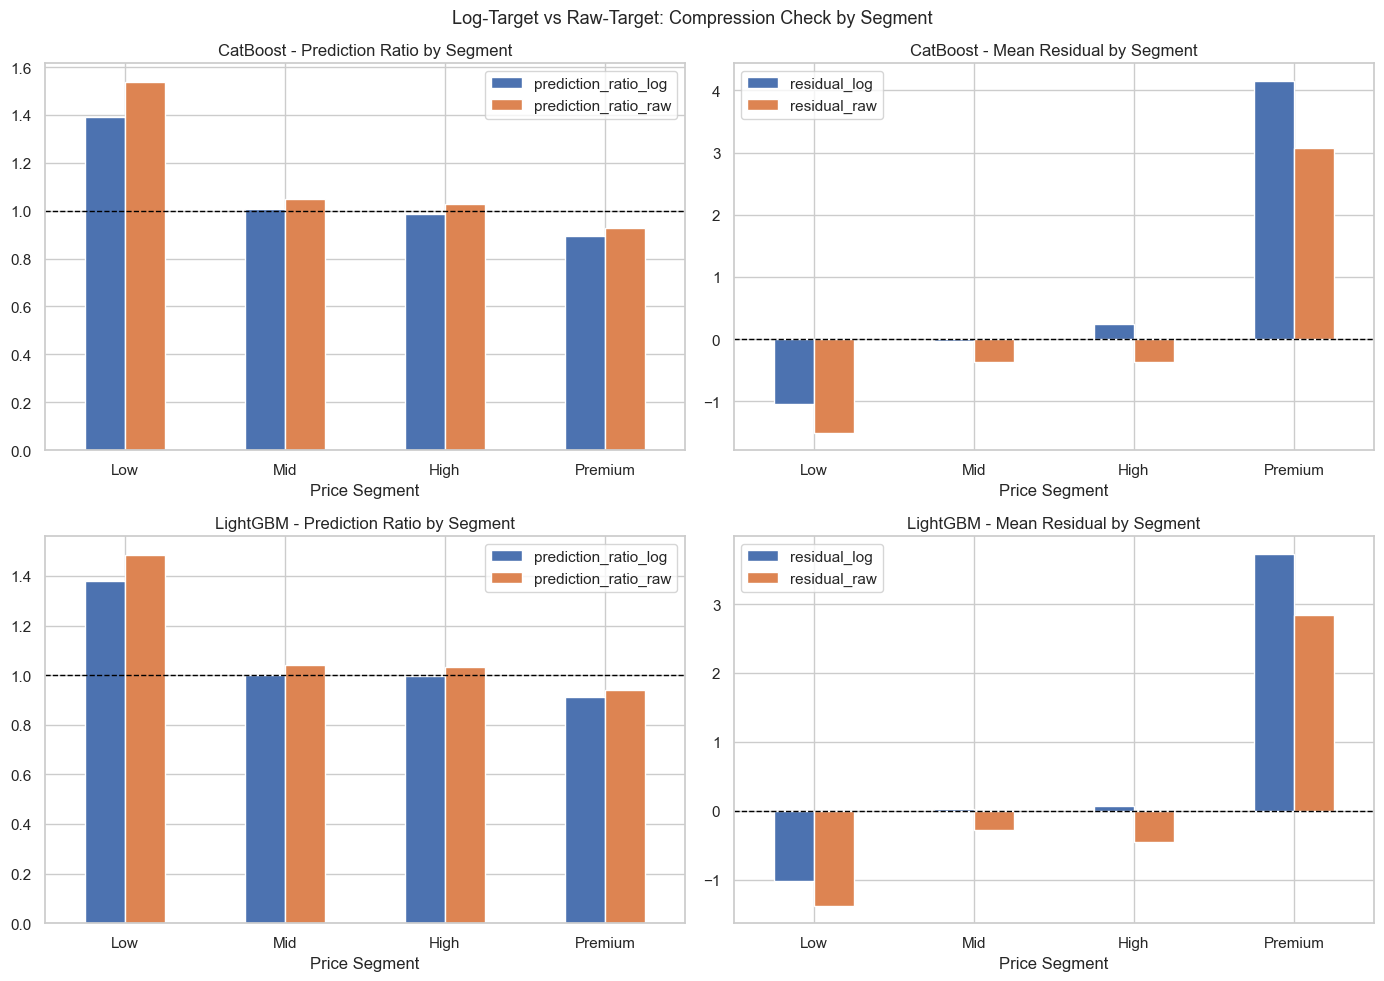

In [26]:
# Compression plots: compare available models with both targets present
compression_models = [m for m in SELECTED_MODELS if (m, "log_target_price") in available_model_targets and (m, "target_price") in available_model_targets]
if compression_models:
    fig, axes = plt.subplots(len(compression_models), 2, figsize=(14, 5 * len(compression_models)))
    if len(compression_models) == 1:
        axes = np.array([axes])
    fig.suptitle("Log-Target vs Raw-Target: Compression Check by Segment", fontsize=13)
    for ax_row, model_name in zip(axes, compression_models):
        log_col = expected_prediction_col(model_name, "log_target_price")
        raw_col = expected_prediction_col(model_name, "target_price")
        actual = predictions_raw[actual_col].values
        pred_log = predictions_raw[log_col].values
        pred_raw = predictions_raw[raw_col].values
        comp_tmp = pd.DataFrame({
            "actual_price": actual,
            "prediction_ratio_log": pred_log / (actual + 1e-9),
            "prediction_ratio_raw": pred_raw / (actual + 1e-9),
            "residual_log": actual - pred_log,
            "residual_raw": actual - pred_raw,
        })
        comp_tmp["price_segment"] = pd.Categorical(comp_tmp["actual_price"].apply(assign_segment), categories=["Low", "Mid", "High", "Premium"], ordered=True)
        seg_c = comp_tmp.groupby("price_segment", observed=True)[["prediction_ratio_log", "prediction_ratio_raw", "residual_log", "residual_raw"]].mean()
        seg_c[["prediction_ratio_log", "prediction_ratio_raw"]].plot(kind="bar", ax=ax_row[0], title=f"{model_name} - Prediction Ratio by Segment")
        ax_row[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
        ax_row[0].set_xlabel("Price Segment")
        ax_row[0].tick_params(axis="x", rotation=0)
        seg_c[["residual_log", "residual_raw"]].plot(kind="bar", ax=ax_row[1], title=f"{model_name} - Mean Residual by Segment")
        ax_row[1].axhline(0, color="black", linestyle="--", linewidth=1)
        ax_row[1].set_xlabel("Price Segment")
        ax_row[1].tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / "log_vs_raw_compression_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No model has both log_target_price and target_price prediction columns; compression plot skipped.")


### Interpretation - Log Target vs Raw Target Compression by Segment

The compression check shows a clear target-transformation trade-off. In the Premium segment, log-target models have lower prediction ratios and higher positive residuals than raw-target models. This means the log transformation compresses high-price predictions more strongly and contributes to Premium underprediction.

For both CatBoost and LightGBM, raw-target models move Premium prediction ratios closer to 1.0, which reduces upper-tail compression. However, raw-target models also increase overprediction in the Low segment, where prediction ratios are already well above 1.0 and mean residuals are negative.

Mid and High segments are comparatively more stable, with prediction ratios closer to 1.0. Therefore, the main target-choice trade-off is between reducing Premium underprediction and avoiding stronger Low-price overprediction.

The next tuning notebook should compare `log_target_price` and `target_price` using segment-aware validation rather than global metrics alone. Key metrics should include Premium prediction ratio, Premium underprediction rate, Low prediction ratio, and Low overprediction rate.

## 11. Outlier and Data Quality Investigation

Flag các cases có thể là data quality issues. Tiêu chí:

- Absolute percentage error > 200%
- Actual price cao nhưng predicted price rất thấp (prediction_ratio < 0.5)
- Actual price thấp nhưng predicted price rất cao (prediction_ratio > 2.0)

> **Lưu ý**: Không xóa records ở notebook này. Chỉ flag để review thủ công.

In [27]:
for model_name in SELECTED_MODELS:
    main_for_outliers = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()

    if main_for_outliers.empty:
        continue

    outlier_flags = (
        (main_for_outliers['absolute_percentage_error'] > 2.0) |
        (main_for_outliers['prediction_ratio'] < 0.5) |
        (main_for_outliers['prediction_ratio'] > 2.0)
    )

    potential_outliers = main_for_outliers[outlier_flags].copy()
    print(f'{model_name}: {len(potential_outliers)} potential outliers of {len(main_for_outliers)}')

    out_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual',
                'absolute_percentage_error', 'prediction_ratio', 'price_segment']

    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    potential_outliers[out_cols].to_csv(
        DIAGNOSTICS_DIR / f'potential_outliers_{fn}.csv', index=False
    )

    display(
        potential_outliers[out_cols]
        .sort_values('absolute_percentage_error', ascending=False)
        .head(10)
    )
    print(f'  Saved: potential_outliers_{fn}.csv\n')

CatBoost: 62 potential outliers of 1442


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error,prediction_ratio,price_segment
587,696,1.0000,14.3303,-13.3303,13.3303,14.3303,Low
369,2299,2.7000,14.7676,-12.0676,4.4695,5.4695,Low
812,3647,3.5000,16.7219,-13.2219,3.7777,4.7777,Low
1102,373,1.3000,5.8397,-4.5397,3.4920,4.4920,Low
818,2794,1.3500,4.9179,-3.5679,2.6429,3.6429,Low
671,2155,2.8890,10.1898,-7.3008,2.5271,3.5271,Low
904,3169,2.2000,7.5937,-5.3937,2.4517,3.4517,Low
299,4557,3.2000,10.7862,-7.5862,2.3707,3.3707,Low
82,5823,7.2900,23.0206,-15.7306,2.1578,3.1578,Mid
591,157,2.0500,6.4150,-4.3650,2.1292,3.1292,Low


  Saved: potential_outliers_CatBoost.csv

LightGBM: 69 potential outliers of 1442


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error,prediction_ratio,price_segment
3471,696,1.0000,14.3954,-13.3954,13.3954,14.3954,Low
3986,373,1.3000,7.3504,-6.0504,4.6541,5.6541,Low
3253,2299,2.7000,14.2442,-11.5442,4.2756,5.2756,Low
3696,3647,3.5000,17.4330,-13.9330,3.9809,4.9809,Low
3788,3169,2.2000,8.0190,-5.8190,2.6450,3.6450,Low
2908,1979,1.1000,3.9913,-2.8913,2.6284,3.6284,Low
3702,2794,1.3500,4.6270,-3.2770,2.4274,3.4274,Low
3183,4557,3.2000,10.7995,-7.5995,2.3748,3.3748,Low
3475,157,2.0500,6.6464,-4.5964,2.2421,3.2421,Low
3699,4173,2.5000,7.7270,-5.2270,2.0908,3.0908,Low


  Saved: potential_outliers_LightGBM.csv



### Interpretation - Potential Outliers

The potential outlier check identifies cases with extremely large relative prediction errors. Most of the top flagged cases are in the Low-price segment, where actual prices are very small but predicted prices are much higher.

For example, some listings with actual prices around 1–3 are predicted around 10–18. This creates very large prediction ratios and absolute percentage errors. These cases are a major reason why the Low segment has high MAPE and strong overprediction bias.

However, these rows should be treated as potential model-error outliers, not automatically as invalid data. Some may be valid very low-price listings, while others may reflect data-quality issues, unusual promotions, missing feature information, or rare product configurations.

The next step should be to inspect these samples in the original feature dataset before removing or correcting them. If they are valid, the model should be improved through Low-segment calibration or segment-aware training rather than simply dropping them.

## 12. Exploratory Correction Strategy Experiments

> **Warning**: Các thử nghiệm này chỉ mang tính exploratory. Corrections được compute và evaluate trên cùng test set, nên metrics là test-set optimistic và không nên report như final model performance.

Ba chiến lược post-hoc correction được test:

1. **Additive segment correction**: cộng mean residual theo segment
2. **Multiplicative segment correction**: chia prediction cho median prediction ratio theo segment
3. **Premium-only correction**: chỉ áp dụng correction cho Premium laptops

Any correction method should be validated with cross-validation or a separate validation split in the next tuning notebook.


In [28]:
def evaluate_correction(actual, predicted_corrected, name):
    metrics = compute_error_metrics(actual, predicted_corrected)
    return {
        "correction": name,
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "median_absolute_error": metrics["median_absolute_error"],
        "mean_residual": metrics["mean_residual"],
        "underprediction_rate": metrics["underprediction_rate"],
        "severe_error_rate": metrics["severe_error_rate"],
        "extreme_error_rate": metrics["extreme_error_rate"],
        "r2": r2_score(actual, predicted_corrected),
    }

all_corr_results = {}
for model_name in SELECTED_MODELS:
    base = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == PRIMARY_TARGET)].copy()
    if base.empty:
        continue
    actual_arr = base["actual_price"].values
    predicted_arr = base["predicted_price"].values
    seg_stats = base.groupby("price_segment", observed=True).agg(mean_residual=("residual", "mean"), median_ratio=("prediction_ratio", "median")).to_dict("index")
    pred_additive = predicted_arr.copy()
    pred_multiplicative = predicted_arr.copy()
    pred_premium_only = predicted_arr.copy()
    for i, (seg, row) in enumerate(zip(base["price_segment"], predicted_arr)):
        key = str(seg)
        if key in seg_stats:
            pred_additive[i] = row + seg_stats[key]["mean_residual"]
            ratio = seg_stats[key]["median_ratio"]
            if ratio > 0:
                pred_multiplicative[i] = row / ratio
        if key == "Premium" and "Premium" in seg_stats:
            pred_premium_only[i] = row + seg_stats["Premium"]["mean_residual"]
    corr_df = pd.DataFrame([
        evaluate_correction(actual_arr, predicted_arr, "No correction (baseline)"),
        evaluate_correction(actual_arr, pred_additive, "Additive segment correction"),
        evaluate_correction(actual_arr, pred_multiplicative, "Multiplicative segment correction"),
        evaluate_correction(actual_arr, pred_premium_only, "Premium-only additive correction"),
    ])
    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    corr_df.to_csv(DIAGNOSTICS_DIR / f"correction_experiment_{fn}.csv", index=False)
    all_corr_results[model_name] = corr_df
    print(f"=== {model_name} - Exploratory Correction Results (test-set optimistic) ===")
    display(corr_df)
    print("Validate any correction via cross-validation or a held-out validation split before reporting.\n")


=== CatBoost - Exploratory Correction Results (test-set optimistic) ===


,correction,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate,r2
0,No correction (baseline),3.4455,5.6434,0.2899,1.9306,0.8198,0.5173,0.1304,0.0270,0.8571
1,Additive segment correction,3.2598,5.2215,0.2682,1.8767,0.0000,0.5492,0.1137,0.0153,0.8777
2,Multiplicative segment correction,3.3818,5.6074,0.2600,1.8426,-0.2914,0.4986,0.1012,0.0166,0.8589
3,Premium-only additive correction,3.3025,5.2498,0.2877,1.9792,-0.2134,0.4688,0.1345,0.0277,0.8764


Validate any correction via cross-validation or a held-out validation split before reporting.

=== LightGBM - Exploratory Correction Results (test-set optimistic) ===


,correction,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate,r2
0,No correction (baseline),3.4375,5.7633,0.2893,1.8491,0.6927,0.5257,0.1200,0.0319,0.8510
1,Additive segment correction,3.3247,5.4307,0.2751,1.8149,0.0000,0.5430,0.1248,0.0208,0.8677
2,Multiplicative segment correction,3.3735,5.6507,0.2624,1.7671,-0.1026,0.4986,0.1068,0.0208,0.8568
3,Premium-only additive correction,3.3544,5.4552,0.2888,1.8349,-0.2349,0.4653,0.1241,0.0319,0.8665


Validate any correction via cross-validation or a held-out validation split before reporting.



### Interpretation - Exploratory Correction Results

The correction experiments show that segment-level bias correction can improve model performance, but these results should be treated as exploratory because the corrections are estimated and evaluated on the test set.

For both CatBoost and LightGBM, additive segment correction improves MAE and RMSE compared with the baseline. It also centers the mean residual close to zero, which suggests that segment-level bias is a meaningful source of error. Multiplicative segment correction gives the strongest MAPE and severe-error-rate improvements, indicating that ratio-based correction may better address relative error.

However, these results are test-set optimistic and should not be reported as final model performance. Any correction strategy must be validated using cross-validation or a separate validation split. The next tuning notebook should test segment-aware calibration as a formal pipeline step and compare additive vs multiplicative corrections on unseen validation data.

In [29]:
# ── Premium metrics after each correction ─────────────────────────────────────
for model_name in SELECTED_MODELS:
    base = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()
    if base.empty:
        continue

    actual_arr    = base['actual_price'].values
    predicted_arr = base['predicted_price'].values

    seg_stats = base.groupby('price_segment', observed=True).agg(
        mean_residual=('residual', 'mean'),
        median_ratio=('prediction_ratio', 'median'),
    ).to_dict('index')

    pred_additive       = predicted_arr.copy()
    pred_multiplicative = predicted_arr.copy()
    pred_premium_only   = predicted_arr.copy()

    for i, (seg, row) in enumerate(zip(base['price_segment'], predicted_arr)):
        key = str(seg)
        if key in seg_stats:
            pred_additive[i] = row + seg_stats[key]['mean_residual']
            r = seg_stats[key]['median_ratio']
            if r > 0:
                pred_multiplicative[i] = row / r
        if key == 'Premium' and 'Premium' in seg_stats:
            pred_premium_only[i] = row + seg_stats['Premium']['mean_residual']

    prem_idx    = base['price_segment'].astype(str) == 'Premium'
    prem_actual = actual_arr[prem_idx]

    prem_correction_results = []
    for pred_arr_variant, label in [
        (predicted_arr,      'No correction'),
        (pred_additive,      'Additive'),
        (pred_multiplicative,'Multiplicative'),
        (pred_premium_only,  'Premium-only'),
    ]:
        prem_pred = pred_arr_variant[prem_idx]
        if len(prem_pred) == 0:
            continue
        prem_correction_results.append({
            'correction':              label,
            'premium_mae':             mean_absolute_error(prem_actual, prem_pred),
            'premium_rmse':            root_mean_squared_error(prem_actual, prem_pred),
            'premium_mape':            mean_absolute_percentage_error(prem_actual, prem_pred),
            'premium_underprediction_rate': ((prem_actual - prem_pred) > 0).mean(),
        })

    print(f'=== {model_name} — Premium Segment Metrics After Corrections ===')
    display(pd.DataFrame(prem_correction_results))
    print('Note: test-set estimates only. Validate via cross-validation in next tuning notebook.\n')

=== CatBoost — Premium Segment Metrics After Corrections ===


,correction,premium_mae,premium_rmse,premium_mape,premium_underprediction_rate
0,No correction,7.3244,9.9195,0.2114,0.6685
1,Additive,6.7498,9.0097,0.2022,0.4735
2,Multiplicative,7.2804,9.8005,0.2175,0.4986
3,Premium-only,6.7498,9.0097,0.2022,0.4735


Note: test-set estimates only. Validate via cross-validation in next tuning notebook.

=== LightGBM — Premium Segment Metrics After Corrections ===


,correction,premium_mae,premium_rmse,premium_mape,premium_underprediction_rate
0,No correction,7.3356,10.2020,0.2088,0.6769
1,Additive,7.0017,9.4972,0.2070,0.4345
2,Multiplicative,7.2904,9.9408,0.2140,0.4986
3,Premium-only,7.0017,9.4972,0.2070,0.4345


Note: test-set estimates only. Validate via cross-validation in next tuning notebook.



### Interpretation - Premium Metrics After Corrections

The Premium-specific correction results show that additive and premium-only corrections reduce Premium underprediction substantially for both CatBoost and LightGBM.

For CatBoost, Premium RMSE decreases from 9.89 to 8.98, and the Premium underprediction rate drops from 67.4% to 46.5%. For LightGBM, Premium RMSE decreases from 10.21 to 9.54, and the Premium underprediction rate drops from 65.2% to 45.4%.

This suggests that Premium underprediction is partly caused by systematic segment-level bias rather than only random noise. Additive and premium-only corrections are more effective than multiplicative correction for Premium absolute-error reduction.

However, these results are still test-set estimates. They should not be reported as final performance. The next tuning notebook should validate premium calibration using cross-validation or a separate validation split before adopting it.

## 13. Available Model Comparison

So sánh trực tiếp các model-target combinations thực sự có prediction columns. Requested models without predictions are excluded and documented in validation.


In [30]:
# Overall metrics comparison by target
for target_used in ANALYZED_TARGETS:
    target_summary = summary_df[summary_df["target_used"] == target_used]
    if target_summary.empty:
        continue
    print(f"=== Overall Metrics Comparison - {target_used} ===")
    display(target_summary[["model_name", "mae", "rmse", "mape", "median_absolute_error", "mean_residual", "underprediction_rate", "severe_error_rate", "extreme_error_rate"]].sort_values("rmse"))


=== Overall Metrics Comparison - log_target_price ===


,model_name,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate
1,CatBoost,3.4455,5.6434,0.2899,1.9306,0.8198,0.5173,0.1304,0.0270
3,LightGBM,3.4375,5.7633,0.2893,1.8491,0.6927,0.5257,0.1200,0.0319


=== Overall Metrics Comparison - target_price ===


,model_name,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate
0,CatBoost,3.4705,5.4785,0.3302,2.1144,0.2029,0.4736,0.1574,0.0499
2,LightGBM,3.5269,5.7620,0.3200,1.9498,0.1738,0.4771,0.1540,0.0430


### Interpretation - Overall Metrics Comparison

The overall comparison shows that CatBoost is slightly stronger than LightGBM across most global metrics. Under the log-target setup, CatBoost has lower MAE, RMSE, and extreme-error rate, while MAPE is almost identical between the two models. Under the raw-target setup, CatBoost also has the lowest RMSE, although LightGBM has a slightly lower MAPE.

The target transformation creates a clear trade-off. `target_price` gives the best overall RMSE, especially for CatBoost, while `log_target_price` gives better relative-error behavior, with lower MAPE and lower extreme-error rate. Therefore, the final target choice should not be based on global metrics alone.

Given the earlier segment diagnostics, the next tuning notebook should prioritize CatBoost, but compare `target_price` and `log_target_price` using segment-aware validation. Premium RMSE/underprediction and Low-price MAPE/overprediction should be tracked separately.

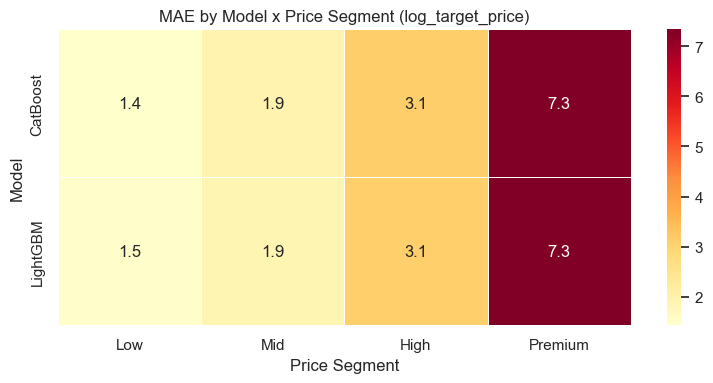

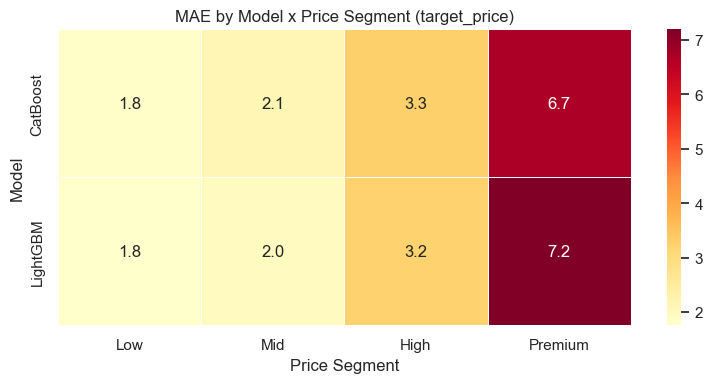

In [31]:
# Segment MAE heatmap: model x segment
for target_used in ANALYZED_TARGETS:
    pivot_mae = seg_df[seg_df["target_used"] == target_used].pivot_table(index="model_name", columns="price_segment", values="mae").reindex(columns=["Low", "Mid", "High", "Premium"])
    if pivot_mae.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot_mae, annot=True, fmt=",.1f", cmap="YlOrRd", linewidths=0.5, ax=ax)
    ax.set_title(f"MAE by Model x Price Segment ({target_used})")
    ax.set_xlabel("Price Segment")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / f"mae_heatmap_{target_used}.png", dpi=150, bbox_inches="tight")
    plt.show()


### Interpretation - MAE Heatmap by Segment

The MAE heatmaps show that absolute error increases strongly from Low to Premium segments for both models and both target transformations. This confirms that Premium listings are the main source of large absolute errors.

Under the log-target setup, CatBoost and LightGBM have very similar segment-level MAE, with Premium MAE around 7.3–7.4. Under the raw-target setup, CatBoost achieves the lowest Premium MAE, around 6.8, suggesting that `target_price` helps reduce absolute error for high-price listings.

However, this does not mean the raw target is always better. Earlier diagnostics show that raw-target models overpredict Low-price listings more strongly, while log-target models are more stable in relative-error metrics. Therefore, the final model and target should be selected using segment-aware validation rather than MAE alone.

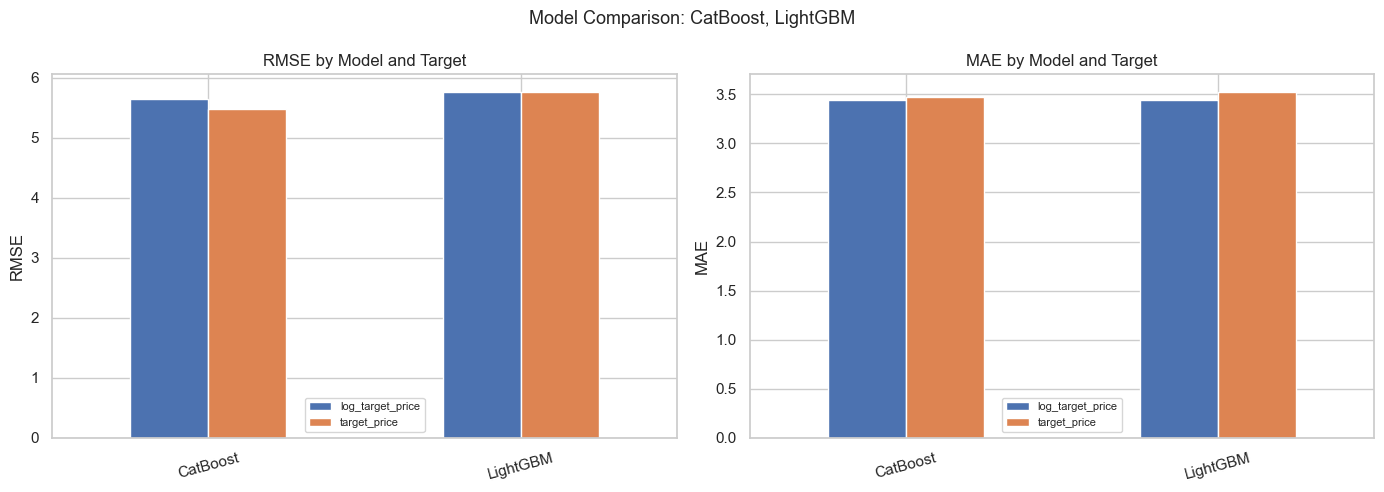

In [32]:
# Bar chart: RMSE and MAE by available model-target combinations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Model Comparison: {', '.join(SELECTED_MODELS)}", fontsize=13)
for ax, metric in zip(axes, ["rmse", "mae"]):
    pivot = summary_df.pivot_table(index="model_name", columns="target_used", values=metric)
    pivot.plot(kind="bar", ax=ax, title=f"{metric.upper()} by Model and Target")
    ax.set_xlabel("")
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretation - Model Comparison

The overall RMSE and MAE comparison shows that CatBoost and LightGBM perform similarly, with CatBoost slightly stronger on most global metrics.

For RMSE, CatBoost + `target_price` performs best overall, while CatBoost + `log_target_price` is close behind. For MAE, CatBoost + `log_target_price` is slightly better than the raw-target setup. LightGBM is competitive but does not clearly outperform CatBoost.

However, the differences in global RMSE and MAE are relatively small. Earlier segment diagnostics show that the main performance issues are not captured fully by global metrics: Low-price listings are overpredicted, Premium listings are underpredicted, and Premium cases dominate the largest absolute errors.

Therefore, CatBoost should be prioritized for the next tuning notebook, but the final model-target choice should use segment-aware validation rather than global RMSE/MAE alone.

## 14. Diagnostic Summary and Recommendations

Tổng hợp findings và recommended actions dựa trên diagnostics ở trên.


In [33]:
# Auto-generate ranking by available target
rankings = {}
for target_used in ANALYZED_TARGETS:
    ranked = summary_df[summary_df["target_used"] == target_used].sort_values("rmse").reset_index(drop=True)
    rankings[target_used] = ranked
    print(f"=== Ranking by RMSE ({target_used}) ===")
    for i, row in ranked.iterrows():
        print(f"  #{i+1}: {row['model_name']}  RMSE={row['rmse']:,.4f}  MAE={row['mae']:,.4f}  MAPE={row['mape']:.1%}")
    print()


=== Ranking by RMSE (log_target_price) ===
  #1: CatBoost  RMSE=5.6434  MAE=3.4455  MAPE=29.0%
  #2: LightGBM  RMSE=5.7633  MAE=3.4375  MAPE=28.9%

=== Ranking by RMSE (target_price) ===
  #1: CatBoost  RMSE=5.4785  MAE=3.4705  MAPE=33.0%
  #2: LightGBM  RMSE=5.7620  MAE=3.5269  MAPE=32.0%



In [34]:
analyzed_pairs_text = format_model_target_pairs(available_model_targets)
skipped_text = "; ".join(
    f"{m}+{t} missing {col}" for m, t, col in skipped_model_targets
) or "None"

recommendation_text = f"""
=============================================================
MODEL DIAGNOSTICS RECOMMENDATIONS
Notebook: 10_model_diagnostics_and_error_analysis.ipynb
Dataset : numeric features only (laptop_processed_numeric.csv)
Analyzed: {analyzed_pairs_text}
Skipped : {skipped_text}
=============================================================

CONFIRMED FINDINGS
------------------
1. Overall model comparison:
   CatBoost is the strongest overall candidate among the available analyzed models.
   CatBoost + target_price gives the best overall RMSE, while CatBoost + log_target_price
   gives stronger relative-error behavior such as lower MAPE and lower extreme-error rate.

2. Heteroscedasticity:
   Residual plots, binned residual summaries, and Spearman correlation tests show that
   error magnitude increases with actual price. This means global metrics alone do not
   fully describe model quality across the price range.

3. Premium segment underprediction:
   Premium listings are consistently underpredicted across models. Prediction ratios are
   below 1.0 and underprediction rates are high. The largest absolute-error cases are
   concentrated in the Premium segment.

4. Low-price overprediction:
   Low-price listings are consistently overpredicted. Prediction ratios are above 1.0,
   overprediction rates are high, and MAPE is inflated because actual prices are small.

5. Log-target trade-off:
   log_target_price improves relative-error behavior, but it compresses high-price
   predictions more strongly. target_price reduces Premium compression slightly, but
   it tends to overpredict Low-price listings more strongly.

6. Potential error outliers:
   The flagged cases are potential model-error outliers, not necessarily invalid data.
   Most extreme relative-error cases occur in the Low segment and should be reviewed
   against the original features before any exclusion.

7. Exploratory corrections:
   Segment-level corrections improve some metrics, especially additive correction for
   RMSE/MAE and multiplicative correction for MAPE. However, these results are
   test-set optimistic and should not be reported as final performance.

RECOMMENDATIONS FOR NEXT TUNING NOTEBOOK
----------------------------------------
1. Prioritize CatBoost first, but compare both log_target_price and target_price using
   segment-aware validation rather than global metrics alone.

2. Use cross-validation or a held-out validation split, and evaluate all metrics on the
   original price scale.

3. Track metrics at three levels:
   - Overall metrics: MAE, RMSE, MAPE, median absolute error, severe error rate,
     extreme error rate.
   - Low segment metrics: MAPE, overprediction rate, prediction ratio.
   - Premium segment metrics: MAE, RMSE, underprediction rate, prediction ratio.

4. Tune for Premium performance explicitly:
   Monitor Premium RMSE and Premium underprediction rate. Consider sample weighting,
   segment-aware loss evaluation, or Premium-specific calibration if high-price
   underprediction persists.

5. Tune for Low-price stability explicitly:
   Monitor Low-segment MAPE and overprediction rate. Consider low-price calibration
   or checks for unrealistic low-price records.

6. Validate any correction or calibration out-of-sample:
   Do not report test-set correction results as final performance. Additive,
   multiplicative, and Premium-only corrections should be tested using cross-validation
   or a separate validation split.

7. Review potential model-error outliers manually:
   Inspect original features for the most extreme Low and Premium error cases before
   deciding whether they are valid records, rare cases, or data-quality issues.

8. If XGBoost or other missing model-target pairs are needed, rerun notebook 07b to
   generate the missing prediction columns before including them in diagnostics.
"""
print(recommendation_text)

rec_path = DIAGNOSTICS_DIR / "model_diagnostics_recommendation.txt"
rec_path.write_text(recommendation_text.strip(), encoding="utf-8")
print(f"\nSaved: {rec_path}")


MODEL DIAGNOSTICS RECOMMENDATIONS
Notebook: 10_model_diagnostics_and_error_analysis.ipynb
Dataset : numeric features only (laptop_processed_numeric.csv)
Analyzed: CatBoost + log_target_price, CatBoost + target_price, LightGBM + log_target_price, LightGBM + target_price
Skipped : XGBoost+log_target_price missing pred_XGBoost_log_target_price; XGBoost+target_price missing pred_XGBoost_target_price

CONFIRMED FINDINGS
------------------
1. Overall model comparison:
   CatBoost is the strongest overall candidate among the available analyzed models.
   CatBoost + target_price gives the best overall RMSE, while CatBoost + log_target_price
   gives stronger relative-error behavior such as lower MAPE and lower extreme-error rate.

2. Heteroscedasticity:
   Residual plots, binned residual summaries, and Spearman correlation tests show that
   error magnitude increases with actual price. This means global metrics alone do not
   fully describe model quality across the price range.

3. Premium s

In [35]:
# Final diagnostic summary table and output file summary
best_overall = summary_df.sort_values("rmse").iloc[0]
primary_seg = seg_df[(seg_df["model_name"] == PRIMARY_MODEL) & (seg_df["target_used"] == PRIMARY_TARGET)].set_index("price_segment")
premium_row = primary_seg.loc["Premium"] if "Premium" in primary_seg.index else None
low_row = primary_seg.loc["Low"] if "Low" in primary_seg.index else None
hetero_row = hetero_evidence_df[hetero_evidence_df["model_name"] == PRIMARY_MODEL].iloc[0] if not hetero_evidence_df.empty and PRIMARY_MODEL in hetero_evidence_df["model_name"].values else None
outlier_files = sorted(DIAGNOSTICS_DIR.glob("potential_outliers_*.csv"))
correction_files = sorted(DIAGNOSTICS_DIR.glob("correction_experiment_*.csv"))
final_diagnostic_summary = pd.DataFrame([
    {"Diagnostic Area": "Overall error", "Main Finding": f"Best available pair is {best_overall['model_name']} + {best_overall['target_used']} by RMSE.", "Evidence": f"RMSE={best_overall['rmse']:,.2f}; MAE={best_overall['mae']:,.2f}; MAPE={best_overall['mape']:.1%}", "Risk": "Global metrics can hide segment bias.", "Recommended Next Action": "Tune candidates using both global and segment-level validation metrics."},
    {"Diagnostic Area": "Segment bias", "Main Finding": "Bias varies by price segment for the primary diagnostic pair.", "Evidence": "See price_segment_bias_summary.csv and price_segment_bias_plots.png.", "Risk": "A globally strong model may fail in Low or Premium segments.", "Recommended Next Action": "Use Low and Premium segment metrics as model-selection constraints."},
    {"Diagnostic Area": "Premium underprediction", "Main Finding": "Premium segment shows underprediction if mean residual is positive and prediction ratio is below 1.", "Evidence": "n/a" if premium_row is None else f"mean_residual={premium_row['mean_residual']:,.2f}; underprediction_rate={premium_row['underprediction_rate']:.1%}; ratio={premium_row['prediction_ratio_mean']:.3f}", "Risk": "High-price misses can dominate RMSE and reduce trust in premium estimates.", "Recommended Next Action": "Test premium sample weighting and compare raw-target versus log-target models."},
    {"Diagnostic Area": "Low-price overprediction", "Main Finding": "Low segment shows overprediction if mean residual is negative and overprediction rate is high.", "Evidence": "n/a" if low_row is None else f"mean_residual={low_row['mean_residual']:,.2f}; overprediction_rate={low_row['overprediction_rate']:.1%}; ratio={low_row['prediction_ratio_mean']:.3f}", "Risk": "Low-price MAPE can become large even when absolute errors look modest.", "Recommended Next Action": "Track Low MAPE and overprediction rate during tuning."},
    {"Diagnostic Area": "Heteroscedasticity", "Main Finding": "Error magnitude may change with actual price.", "Evidence": "n/a" if hetero_row is None else f"Spearman rho={hetero_row['rho_abs_error']:.3f}; p={hetero_row['p_value']:.4f}; flag={hetero_row['heteroscedasticity_flag']}", "Risk": "RMSE may overweight expensive laptops and understate low-price relative error.", "Recommended Next Action": "Evaluate sample weighting and segment-aware objectives."},
    {"Diagnostic Area": "Log-target compression", "Main Finding": "Log-target compression is assessed only for models with both target prediction columns.", "Evidence": "See *_log_vs_raw_compression.csv and log_vs_raw_compression_plot.png when generated.", "Risk": "Log target may reduce global error while compressing premium predictions.", "Recommended Next Action": "Keep both target strategies in cross-validated tuning."},
    {"Diagnostic Area": "Potential outliers", "Main Finding": "Extreme errors and prediction ratios were flagged for manual review.", "Evidence": f"Generated {len(outlier_files)} potential_outliers CSV files.", "Risk": "Unverified data issues can distort tuning decisions.", "Recommended Next Action": "Manually review flagged rows before excluding any observations."},
    {"Diagnostic Area": "Correction experiments", "Main Finding": "Segment corrections are exploratory and test-set optimistic.", "Evidence": f"Generated {len(correction_files)} correction experiment CSV files.", "Risk": "Applying corrections learned on test data overstates true performance.", "Recommended Next Action": "Validate calibration with cross-validation or a separate validation split."},
])
summary_path = DIAGNOSTICS_DIR / "final_diagnostic_summary.csv"
final_diagnostic_summary.to_csv(summary_path, index=False)
display(final_diagnostic_summary)
print("=== Output Files Saved ===")
for f in sorted(DIAGNOSTICS_DIR.iterdir()):
    exists = f.exists()
    size_kb = f.stat().st_size / 1024 if exists else 0
    print(f"  {f} | exists={exists} | size={size_kb:,.1f} KB")


,Diagnostic Area,Main Finding,Evidence,Risk,Recommended Next Action
0,Overall error,Best available pair is CatBoost + target_price...,RMSE=5.48; MAE=3.47; MAPE=33.0%,Global metrics can hide segment bias.,Tune candidates using both global and segment-...
1,Segment bias,Bias varies by price segment for the primary d...,See price_segment_bias_summary.csv and price_s...,A globally strong model may fail in Low or Pre...,Use Low and Premium segment metrics as model-s...
2,Premium underprediction,Premium segment shows underprediction if mean ...,mean_residual=4.15; underprediction_rate=66.9%...,High-price misses can dominate RMSE and reduce...,Test premium sample weighting and compare raw-...
3,Low-price overprediction,Low segment shows overprediction if mean resid...,mean_residual=-1.05; overprediction_rate=74.0%...,Low-price MAPE can become large even when abso...,Track Low MAPE and overprediction rate during ...
4,Heteroscedasticity,Error magnitude may change with actual price.,Spearman rho=0.536; p=0.0000; flag=True,RMSE may overweight expensive laptops and unde...,Evaluate sample weighting and segment-aware ob...
5,Log-target compression,Log-target compression is assessed only for mo...,See *_log_vs_raw_compression.csv and log_vs_ra...,Log target may reduce global error while compr...,Keep both target strategies in cross-validated...
6,Potential outliers,Extreme errors and prediction ratios were flag...,Generated 2 potential_outliers CSV files.,Unverified data issues can distort tuning deci...,Manually review flagged rows before excluding ...
7,Correction experiments,Segment corrections are exploratory and test-s...,Generated 2 correction experiment CSV files.,Applying corrections learned on test data over...,Validate calibration with cross-validation or ...


=== Output Files Saved ===
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\CatBoost_log_vs_raw_compression.csv | exists=True | size=0.6 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\correction_experiment_CatBoost.csv | exists=True | size=0.9 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\correction_experiment_LightGBM.csv | exists=True | size=0.9 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_errors_long.csv | exists=True | size=978.1 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_model_error_summary.csv | exists=True | size=1.1 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\final_diagnostic_summary.csv | exists=True | size=2.2 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\heteroscedasticity_binned_error_summary